In [1]:
"""
Course Clustering Analysis
=========================
Goal: identify the statistical profile of Open Championship winners
      and find 2026 contenders who match it.
"""
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

import re
import time

import requests
import os
import json
from dotenv import load_dotenv

# Set up paths
from pathlib import Path
ROOT = Path.cwd().parent.parent  # caddie-desk root
RAW_DIR = ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT / "analysis" / "scripts"))
import caddie_style
caddie_style.apply()

# Load API key
load_dotenv(ROOT / "analysis" / ".env")
API_KEY = os.getenv("DATAGOLF_API_KEY")

if not API_KEY:
    print("⚠ DATAGOLF_API_KEY not found in .env file")
else:
    print("✓ API key loaded")

# Test 1: Can we hit the player list (we know this works for Pardle)?
url = f"https://feeds.datagolf.com/get-player-list?file_format=json&key={API_KEY}"
response = requests.get(url)
print(f"\nPlayer list endpoint: status {response.status_code}")
if response.status_code == 200:
    data = response.json()
    print(f"  Returned {len(data)} players")
    
print("Setup complete.")
print(f"Working from: {ROOT}")

✓ API key loaded

Player list endpoint: status 200
  Returned 3474 players
Setup complete.
Working from: /Users/rosie.kipling/Desktop/caddiedesk


In [2]:
import warnings
warnings.filterwarnings("ignore", message=".*Font family.*")

In [3]:
## Pull data via API

import time

TOURS_TO_PULL = ["pga", "euro", "kft", "liv"]  # add more if you want — adt, jpn, asa, etc.

all_events = []

for tour in TOURS_TO_PULL:
    url = f"https://feeds.datagolf.com/historical-raw-data/event-list?tour={tour}&file_format=json&key={API_KEY}"
    response = requests.get(url)
    
    if response.status_code == 200:
        events = response.json()
        # Attach tour info if it's not already there
        for e in events:
            if "tour" not in e:
                e["tour"] = tour
        all_events.extend(events)
        print(f"✓ {tour}: {len(events)} events")
    else:
        print(f"✗ {tour}: status {response.status_code} — {response.text[:200]}")
    
    time.sleep(0.3)  # be polite to the API

print(f"\nTotal events across tours: {len(all_events)}")

# Save raw output
events_path = RAW_DIR / "historical-events-list.json"
events_path.write_text(json.dumps(all_events, indent=2))
print(f"Saved to {events_path.relative_to(ROOT)}")

✓ pga: 1068 events
✓ euro: 340 events
✓ kft: 240 events
✓ liv: 60 events

Total events across tours: 1708
Saved to data/raw/historical-events-list.json


## Explore Data

In [4]:
## Explore event data

ev_df = pd.DataFrame(all_events)
print(f"Total events: {len(ev_df)}")
print(f"\nColumns: {ev_df.columns.tolist()}")
print(f"\nDtypes:")
print(ev_df.dtypes)

# Show structure of a single event
print(f"\nSample event:")
print(json.dumps(all_events[0], indent=2))

Total events: 1708

Columns: ['calendar_year', 'date', 'event_id', 'event_name', 'sg_categories', 'tour', 'traditional_stats']

Dtypes:
calendar_year        int64
date                   str
event_id             int64
event_name             str
sg_categories          str
tour                   str
traditional_stats      str
dtype: object

Sample event:
{
  "calendar_year": 2026,
  "date": "2026-05-17",
  "event_id": 33,
  "event_name": "PGA Championship",
  "sg_categories": "yes",
  "tour": "pga",
  "traditional_stats": "yes"
}


In [5]:
# Year range
year_col = None
for candidate in ["calendar_year", "year", "season"]:
    if candidate in ev_df.columns:
        year_col = candidate
        break

if year_col:
    print(f"Year range: {ev_df[year_col].min()} to {ev_df[year_col].max()}")
    print(f"\nEvents per year (last 10 years):")
    print(ev_df[ev_df[year_col] >= ev_df[year_col].max() - 9][year_col].value_counts().sort_index())

# Tour breakdown
print(f"\nEvents by tour:")
print(ev_df["tour"].value_counts())

# Course names (if available)
for col in ["course", "course_name", "venue"]:
    if col in ev_df.columns:
        print(f"\nUnique courses ({col}): {ev_df[col].nunique()}")
        print(f"Most common courses:")
        print(ev_df[col].value_counts().head(15))
        break

Year range: 1983 to 2026

Events per year (last 10 years):
calendar_year
2017    110
2018    112
2019    111
2020     91
2021    104
2022    120
2023    125
2024    127
2025    124
2026     50
Name: count, dtype: int64

Events by tour:
tour
pga     1068
euro     340
kft      240
liv       60
Name: count, dtype: int64


In [6]:
# Filter to SG-enabled events only
sg_events = ev_df[ev_df["sg_categories"] == "yes"].copy()
print(f"Need to fetch {len(sg_events)} events with SG data")

# Where to save raw event data
EVENTS_RAW_DIR = RAW_DIR / "events"
EVENTS_RAW_DIR.mkdir(exist_ok=True)

def fetch_event(tour, event_id, year):
    """Fetch one event's rounds data. Returns dict or None on error."""
    url = (f"https://feeds.datagolf.com/historical-raw-data/rounds"
           f"?tour={tour}"
           f"&event_id={event_id}"
           f"&year={year}"
           f"&file_format=json"
           f"&key={API_KEY}")
    
    try:
        response = requests.get(url, timeout=20)
        if response.status_code == 200:
            return response.json()
        else:
            print(f"  ⚠ Status {response.status_code}")
            return None
    except Exception as e:
        print(f"  ✗ Error: {e}")
        return None

def event_filename(tour, event_id, year):
    return EVENTS_RAW_DIR / f"{year}_{tour}_{event_id}.json"

# Dry run: estimate how many we already have vs need to pull
existing = list(EVENTS_RAW_DIR.glob("*.json"))
print(f"Already have: {len(existing)} event files")
print(f"Need to fetch: ~{len(sg_events) - len(existing)} more")

Need to fetch 753 events with SG data
Already have: 753 event files
Need to fetch: ~0 more


### Fetch Events

In [7]:
# Rate limit: 45 requests per minute = 1.33 seconds between requests
# Use 1.5s to give ourselves headroom
SLEEP_BETWEEN = 1.5

# Track how many we've made in the last minute
request_times = []

def rate_limited_fetch(tour, event_id, year, max_retries=3):
    """Fetch with rate limiting and exponential backoff retry."""
    
    # Wait if we're at the limit
    now = time.time()
    request_times[:] = [t for t in request_times if now - t < 60]
    if len(request_times) >= 44:  # buffer of 1
        wait = 60 - (now - request_times[0]) + 0.5
        print(f"  ⏱  Rate limit window — pausing {wait:.1f}s")
        time.sleep(wait)
    
    url = (f"https://feeds.datagolf.com/historical-raw-data/rounds"
           f"?tour={tour}"
           f"&event_id={event_id}"
           f"&year={year}"
           f"&file_format=json"
           f"&key={API_KEY}")
    
    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=20)
            request_times.append(time.time())
            
            if response.status_code == 200:
                return response.json()
            
            if response.status_code == 429:
                wait = 30 * (attempt + 1)  # 30s, then 60s, then 90s
                print(f"  ⚠ 429 — backing off {wait}s (attempt {attempt+1}/{max_retries})")
                time.sleep(wait)
                continue
            
            print(f"  ⚠ Status {response.status_code}")
            return None
            
        except Exception as e:
            print(f"  ✗ Error: {e}")
            time.sleep(5)
    
    return None


# Now run the fetch with the rate-limited function
fetch_list = sg_events.sort_values("calendar_year", ascending=False).to_dict("records")
TEST_LIMIT = None  # set to None for full run

if TEST_LIMIT:
    fetch_list = fetch_list[:TEST_LIMIT]

fetched = 0
skipped = 0
errors = 0

for i, event in enumerate(fetch_list, 1):
    out_path = event_filename(event["tour"], event["event_id"], event["calendar_year"])
    
    if out_path.exists():
        skipped += 1
        continue
    
    print(f"[{i}/{len(fetch_list)}] {event['calendar_year']} {event['event_name']} ({event['tour']})")
    
    data = rate_limited_fetch(event["tour"], event["event_id"], event["calendar_year"])
    
    if data is None:
        errors += 1
        continue
    
    out_path.write_text(json.dumps(data, indent=2))
    fetched += 1
    
    time.sleep(SLEEP_BETWEEN)
    
    # Print progress every 50 events
    if i % 50 == 0:
        print(f"\n  Progress: {fetched} fetched, {skipped} skipped, {errors} errors")
        print(f"  Estimated time remaining: {(len(fetch_list)-i)*SLEEP_BETWEEN/60:.1f} min\n")

print(f"\nDone. Fetched: {fetched}, Skipped: {skipped}, Errors: {errors}")


Done. Fetched: 0, Skipped: 753, Errors: 0


In [8]:
fetched_files = list(EVENTS_RAW_DIR.glob("*.json"))
print(f"Total event files: {len(fetched_files)}")

# Spot-check file sizes
sizes = [f.stat().st_size for f in fetched_files]
print(f"Average file size: {sum(sizes)/len(sizes)/1024:.1f} KB")
print(f"Total data: {sum(sizes)/1024/1024:.1f} MB")

# Sample a few to confirm structure
print("\nSample 3 random files:")
import random
for f in random.sample(fetched_files, 3):
    data = json.loads(f.read_text())
    print(f"  {f.name}: {data.get('event_name')} ({len(data.get('scores', []))} players)")

Total event files: 753
Average file size: 260.7 KB
Total data: 191.7 MB

Sample 3 random files:
  2015_pga_25.json: FedEx St. Jude Classic (155 players)
  2023_pga_100.json: The Open Championship (156 players)
  2017_pga_28.json: BMW Championship (69 players)


In [9]:
# Confirm we have everything
event_files = sorted(EVENTS_RAW_DIR.glob("*.json"))
print(f"Event files: {len(event_files)}")

# Build a master DataFrame of every (player, event, round) record
records = []

for filepath in event_files:
    data = json.loads(filepath.read_text())
    
    event_meta = {
        "event_id": data.get("event_id"),
        "event_name": data.get("event_name"),
        "tour": data.get("tour"),
        "year": data.get("year") or data.get("season"),
        "event_completed": data.get("event_completed"),
    }
    
    for player in data.get("scores", []):
        player_meta = {
            "dg_id": player.get("dg_id"),
            "player_name": player.get("player_name"),
            "fin_text": player.get("fin_text"),
        }
        
        # Loop through rounds (round_1, round_2, etc.)
        for key, round_data in player.items():
            if not key.startswith("round_") or not isinstance(round_data, dict):
                continue
            round_num = int(key.split("_")[1])
            
            row = {
                **event_meta,
                **player_meta,
                "round_num": round_num,
                **{k: v for k, v in round_data.items() if not isinstance(v, dict)},
            }
            records.append(row)

df = pd.DataFrame(records)
print(f"\nTotal player-round records: {len(df):,}")
print(f"Unique events: {df['event_id'].nunique()}")
print(f"Unique courses: {df['course_name'].nunique()}")
print(f"Year range: {df['year'].min()} to {df['year'].max()}")

# Save the master DataFrame as parquet (faster to reload later)
master_path = RAW_DIR / "all-rounds.parquet"
df.to_parquet(master_path)
print(f"\nSaved master to {master_path.relative_to(ROOT)}")

Event files: 753

Total player-round records: 287,506
Unique events: 82
Unique courses: 181
Year range: 2004 to 2026

Saved master to data/raw/all-rounds.parquet


In [10]:
# Helper: convert fin_text to numeric finish position
def parse_finish(fin_text):
    """Convert '1', 'T5', 'CUT', 'WD' etc to numeric position."""
    if not fin_text or pd.isna(fin_text):
        return None
    s = str(fin_text).strip()
    
    # CUT / WD / DQ etc — treat as 80th (typical missed-cut position)
    if any(code in s.upper() for code in ["CUT", "WD", "DQ", "MDF"]):
        return 80
    
    # Strip T (tied) and any asterisks
    s = s.replace("T", "").replace("*", "").strip()
    
    try:
        return int(s)
    except ValueError:
        return None

# Test it
test_cases = ["1", "T5", "CUT", "WD", "T10", "30", "1*"]
for t in test_cases:
    print(f"  {t!r} → {parse_finish(t)}")

  '1' → 1
  'T5' → 5
  'CUT' → 80
  'WD' → 80
  'T10' → 10
  '30' → 30
  '1*' → 1


In [11]:
# Add a unique-per-edition event ID
df["event_year_id"] = df["event_id"].astype(str) + "_" + df["year"].astype(str)

# Confirm uniqueness — should now match our 752 file count
print(f"Unique event_year_ids: {df['event_year_id'].nunique()}")
print(f"Original event_ids: {df['event_id'].nunique()}")


# Aggregate by player + event-edition
agg_stats = ["sg_total", "sg_ott", "sg_app", "sg_arg", "sg_putt", 
             "sg_t2g", "driving_dist", "driving_acc", "gir", "scrambling"]

# Null check
print("Null counts per stat:")
for col in agg_stats:
    if col in df.columns:
        null_pct = df[col].isna().sum() / len(df) * 100
        print(f"  {col}: {null_pct:.1f}% null")

# Aggregate each player's rounds within one event edition
event_level = (df.groupby(["event_year_id", "event_id", "year", "tour", "course_name", 
                           "dg_id", "player_name", "fin_text"])
               [agg_stats]
               .mean()
               .reset_index())

event_level["finish_pos"] = event_level["fin_text"].apply(parse_finish)
event_level = event_level.dropna(subset=["finish_pos"])

print(f"\nEvent-level records: {len(event_level):,}")
print(f"\nSample:")
# print(event_level.head())

Unique event_year_ids: 745
Original event_ids: 82
Null counts per stat:
  sg_total: 0.0% null
  sg_ott: 0.6% null
  sg_app: 0.6% null
  sg_arg: 0.6% null
  sg_putt: 0.6% null
  sg_t2g: 0.6% null
  driving_dist: 45.1% null
  driving_acc: 45.1% null
  gir: 45.3% null
  scrambling: 47.4% null

Event-level records: 94,288

Sample:


In [12]:
# Course name normalisation map
# Maps variant names to a canonical name
COURSE_NAME_CANONICAL = {
    # East Lake
    "East Lake GC": "East Lake Golf Club",
    
    # Riviera
    "Riviera CC": "Riviera Country Club",
    "The Riviera Country Club": "Riviera Country Club",
    
    # Innisbrook
    "Innisbrook Resort (Copperhead Course)": "Innisbrook Resort (Copperhead)",
    "Innisbrook Resort and Golf Club - Copperhead Course": "Innisbrook Resort (Copperhead)",
    "Westin Innisbrook (Copperhead)": "Innisbrook Resort (Copperhead)",
    
    # TPC Sawgrass
    "TPC Sawgrass (THE PLAYERS Stadium Course)": "TPC Sawgrass",
    "TPC Sawgrass - THE PLAYERS Stadium Course": "TPC Sawgrass",
    
    # TPC San Antonio
    "TPC San Antonio (Oaks Course)": "TPC San Antonio (Oaks)",
    "TPC San Antonio - AT&T Oaks": "TPC San Antonio (Oaks)",
    "TPC San Antonio - The Oaks Course": "TPC San Antonio (Oaks)",
    "TPC San Antonio": "TPC San Antonio (Oaks)",
    "JW Marriott TPC San Antonio": "TPC San Antonio (Oaks)",
    
    # TPC Scottsdale
    "TPC Scottsdale (Stadium Course)": "TPC Scottsdale",
    
    # Sea Island (note: Plantation vs Seaside are different courses!)
    "Sea Island Resort (Seaside)": "Sea Island Golf Club (Seaside Course)",
    
    # Silverado
    "Silverado Resort & Spa (North)": "Silverado Resort (North)",
    "Silverado Resort (North Course)": "Silverado Resort (North)",
    "Silverado Resort and Spa (North Course)": "Silverado Resort (North)",
    "Silverado Resort and Spa North": "Silverado Resort (North)",
    "Silverado CC (North)": "Silverado Resort (North)",
    
    # Old White (Greenbrier)
    "The Old White Course": "The Old White TPC",
    "The Old White Golf Course": "The Old White TPC",
    
    # Country Club of Jackson
    "CC of Jackson": "Country Club of Jackson",
    "The Country Club of Jackson": "Country Club of Jackson",
    
    # Hamilton G&CC
    "Hamilton G&CC": "Hamilton Golf & Country Club",
    
    # Harbour Town
    "Harbour Town GL": "Harbour Town Golf Links",
    
    # Liberty National
    "Liberty National GC": "Liberty National Golf Club",
    
    # Muirfield Village
    "Muirfield Village GC": "Muirfield Village Golf Club",
    
    # Sedgefield
    "Sedgefield CC": "Sedgefield Country Club",
    
    # Waialae
    "Waialae CC": "Waialae Country Club",
    
    # Valhalla
    "Valhalla GC": "Valhalla Golf Club",
    
    # Robert Trent Jones
    "Robert Trent Jones GC": "Robert Trent Jones Golf Club",
    
    # Quail Hollow
    "Quail Hollow-PGA Championship": "Quail Hollow Club",
    
    # Olympia Fields
    "Olympia Fields CC (North)": "Olympia Fields Country Club (North)",
    "Olympia Fields Country Club (North Course)": "Olympia Fields Country Club (North)",
    
    # PGA National
    "PGA National  - Champion Course": "PGA National (Champion)",
    "PGA National Resort (The Champion Course)": "PGA National (Champion)",
    "PGA National Resort (The Champion)": "PGA National (Champion)",
    
    # Trump Doral
    "TPC Blue Monster at Doral": "Trump National Doral",
    "Doral Golf Resort and Spa": "Trump National Doral",
    "Trump National Doral - Blue Monster Course": "Trump National Doral",
    
    # Bethpage
    "Bethpage State Park (Black)": "Bethpage Black",
    
    # Torrey Pines (note: North and South are different!)
    "Torrey Pines (South)": "Torrey Pines Golf Course (South Course)",
    
    # Keene Trace
    "Keene Trace Golf Club (Champion Trace)": "Keene Trace Golf Club (Champions Course)",
    
    # Bay Hill
    "Arnold Palmer's Bay Hill Club & Lodge": "Bay Hill Club & Lodge",
    
    # Aronimink
    "Aronimink GC": "Aronimink Golf Club",
    
    # Glen Abbey
    "Glen Abbey GC": "Glen Abbey Golf Club",
    
    # Crooked Stick
    "Crooked Stick GC": "Crooked Stick Golf Club",
    
    # Detroit
    "Detroit GC": "Detroit Golf Club",
    
    # Sherwood
    "Sherwood CC": "Sherwood Country Club",
    
    # Baltusrol
    "Baltusrol GC": "Baltusrol Golf Club",
    
    # Bellerive
    "Bellerive CC": "Bellerive Country Club",
    
    # Plainfield
    "Plainfield CC": "Plainfield Country Club",
    
    # Cherry Hills
    "Cherry Hills CC": "Cherry Hills Country Club",
    
    # Albany
    "Albany GC": "Albany Golf Club",
    
    # Sentosa
    "Sentosa Golf Club": "Sentosa Golf Club",
    
    # St. Andrews
    "St. Andrews Links (Old Course)": "Old Course at St Andrews",
    
    # Royal St. George's gets via override
    
    # Real Club Valderrama
    "Real Club Valderrama": "Valderrama Golf Club",
    
    # Dunes
    "The Dunes Golf and Beach Club": "Dunes Golf and Beach Club",
    
    # Medinah
    "Medinah Country Club (No. 3)": "Medinah Country Club",
    
    # Wentworth, RTJ Trail, etc. — leave as-is if unique already
}

# Apply normalisation to the DataFrame
df["course_name"] = df["course_name"].replace(COURSE_NAME_CANONICAL)

# Save the cleaned data back
df.to_parquet(ROOT / "data" / "raw" / "all-rounds.parquet")

# Verify
print(f"Unique courses after normalisation: {df['course_name'].nunique()}")
print(f"(was 180 before)")

Unique courses after normalisation: 137
(was 180 before)


In [13]:
top_courses = (df.groupby("course_name")
               .agg(events=("event_year_id", lambda x: x.nunique()),
                    rounds=("event_year_id", "count"))
               .sort_values("events", ascending=False))
print(top_courses.head(20))

sufficient = (top_courses["events"] >= 3).sum()
print(f"\nCourses with 3+ events: {sufficient}")
print(f"Courses with 5+ events: {(top_courses['events'] >= 5).sum()}")

                                events  rounds
course_name                                   
TPC Sawgrass                        23    9708
Harbour Town Golf Links             23    9175
Bay Hill Club & Lodge               23    8477
Muirfield Village Golf Club         23    8534
TPC Scottsdale                      23    9367
Waialae Country Club                23    9975
East Lake Golf Club                 22    2601
Innisbrook Resort (Copperhead)      22    9527
Riviera Country Club                22    8837
TPC Southwind                       22    8887
TPC River Highlands                 22    9742
Plantation Course at Kapalua        21    2921
Quail Hollow Club                   21    9304
TPC Deere Run                       21    9544
PGA National (Champion)             20    8586
Sedgefield Country Club             18    8268
TPC Summerlin                       17    7137
TPC San Antonio (Oaks)              16    7060
TPC Boston                          16    5978
Firestone CC 

In [14]:
# # Delete the old metadata so we restart cleanly
# import shutil
# meta_path = ROOT / "data" / "course_metadata.json"
# if meta_path.exists():
#     meta_path.unlink()
#     print("Old metadata cleared.")

In [15]:
# !python analysis/scripts/scrape_course_metadata_agent.py  

In [16]:
## Spot any obvious errors

# Find caddiedesk root from any location
ROOT = Path.cwd()
while ROOT.name != "caddiedesk" and ROOT.parent != ROOT:
    ROOT = ROOT.parent

meta_path = ROOT / "data" / "course_metadata.json"
print(f"Looking for: {meta_path}")
print(f"Exists: {meta_path.exists()}")

meta = json.loads(meta_path.read_text())
df_meta = pd.DataFrame.from_dict(meta, orient="index")

print(f"Total: {len(df_meta)}")
print(f"\nStatus breakdown:")
print(df_meta["status"].value_counts())

print(f"\nMissing key fields:")
for col in ["country", "yardage", "par", "course_type", "designer"]:
    if col in df_meta.columns:
        missing = df_meta[col].isna().sum()
        print(f"  {col}: {missing} missing")

print(f"\nSuspicious yardage values:")
if "yardage" in df_meta.columns:
    weird = df_meta[(df_meta["yardage"] < 6000) | (df_meta["yardage"] > 8000)]
    print(weird[["yardage", "par", "country", "course_type"]].dropna(subset=["yardage"]))

print(f"\nPar distribution:")
print(df_meta["par"].value_counts())

print(f"\nCourse type distribution:")
print(df_meta["course_type"].value_counts())

print(f"\nThe Open venues + Birkdale specifically:")
opens = ["Royal Liverpool", "Royal Birkdale", "Royal Troon", "Royal Portrush Golf Club", 
        "Old Course at St Andrews"]
for venue in opens:
    if venue in meta:
        print(f"\n  {venue}:")
        for k, v in meta[venue].items():
            if k != "course_name":
                print(f"    {k}: {v}")
    else:
        print(f"  {venue}: NOT FOUND")

Looking for: /Users/rosie.kipling/Desktop/caddiedesk/data/course_metadata.json
Exists: True
Total: 185

Status breakdown:
status
found                     160
stats_only_no_metadata     25
Name: count, dtype: int64

Missing key fields:
  country: 25 missing
  yardage: 27 missing
  par: 25 missing
  course_type: 25 missing
  designer: 26 missing

Suspicious yardage values:
Empty DataFrame
Columns: [yardage, par, country, course_type]
Index: []

Par distribution:
par
72.0    98
71.0    36
70.0    23
73.0     3
Name: count, dtype: int64

Course type distribution:
course_type
parkland     96
links        21
coastal      15
stadium      13
desert        8
mountain      4
heathland     3
Name: count, dtype: int64

The Open venues + Birkdale specifically:

  Royal Liverpool:
    coastal: True
    country: England
    course_type: links
    designed_year: 1869
    designer: Robert Chambers and George Morris
    elevation_m: 0
    par: 71
    region: UK
    shap_profile: {'driving_acc_shap': 32

In [17]:
import json
from pathlib import Path
from difflib import SequenceMatcher

# Find caddiedesk root
ROOT = Path.cwd()
while ROOT.name != "caddiedesk" and ROOT.parent != ROOT:
    ROOT = ROOT.parent

meta_path = ROOT / "data" / "course_metadata.json"
meta = json.loads(meta_path.read_text())
existing_courses = list(meta.keys())

# Courses we want to add
to_add = [
    "Augusta National Golf Club",
    "Royal Birkdale Golf Club",
    "Royal Lytham & St Annes Golf Club",
    "Carnoustie Golf Links",
    "Turnberry",
    "Royal Dornoch Golf Club",
    "Royal County Down Golf Club",
    "Portmarnock Golf Club",
    "Lahinch Golf Club",
    "Royal Aberdeen Golf Club",
    "Cruden Bay Golf Club",
    "Kingsbarns Golf Links",
    "Castle Stuart",
    "Royal Portrush Golf Club Dunluce Links",
    "Ballybunion Golf Club",
    "Sunningdale Golf Club",
    "Walton Heath Golf Club",
    "Royal St George's Golf Club",
    "St George's Hill Golf Club",
    "Loch Lomond Golf Club",
    "Gleneagles",
    "K Club",
    "Real Club Golf de Sotogrande",
    "Real Club de la Puerta de Hierro",
    "Pinehurst No. 2",
    "Whistling Straits",
    "Bethpage Black",
    "Hazeltine National Golf Club",
    "The Olympic Club",
    "Winged Foot Golf Club",
    "Shinnecock Hills Golf Club",
    "Pebble Beach Golf Links",
    "Bay Hill Club and Lodge",
    "Pinehurst Resort",
]


def similarity(a: str, b: str) -> float:
    """Return similarity ratio between two strings (0-1)."""
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()


def find_likely_matches(target: str, existing: list[str], threshold: float = 0.7) -> list[tuple[str, float]]:
    """Find existing courses that look similar to the target.
    
    Focuses on distinctive name tokens, ignoring common words like 'Golf Club'.
    """
    # Strip common words and punctuation to get the distinctive part of the name
    stopwords = {"golf", "club", "course", "the", "of", "and", "&", "at", 
                 "country", "links", "resort", "national", "international",
                 "lodge", "spa", "estates", "estate"}
    
    def distinctive_tokens(name: str) -> set:
        cleaned = name.replace("&", " ").replace("(", " ").replace(")", " ")
        tokens = {w.lower().strip(".,'") for w in cleaned.split()}
        return {t for t in tokens if t and t not in stopwords and len(t) > 1}
    
    target_tokens = distinctive_tokens(target)
    
    matches = []
    for existing_name in existing:
        existing_tokens = distinctive_tokens(existing_name)
        
        if not target_tokens or not existing_tokens:
            continue
        
        # Calculate Jaccard similarity on the distinctive tokens
        intersection = target_tokens & existing_tokens
        union = target_tokens | existing_tokens
        jaccard = len(intersection) / len(union) if union else 0
        
        # Only consider matches with REAL overlap on distinctive tokens
        if jaccard >= 0.4 or len(intersection) >= 2:
            # Also compute full string similarity for ranking
            full_sim = SequenceMatcher(None, target.lower(), existing_name.lower()).ratio()
            # Weighted: prioritise distinctive token match
            score = (jaccard * 0.7) + (full_sim * 0.3)
            matches.append((existing_name, score))
    
    return sorted(matches, key=lambda x: -x[1])


# Check each course
already_have = []
need_to_add = []
ambiguous = []

print("Checking which courses are already in your metadata...\n")

for course in to_add:
    matches = find_likely_matches(course, existing_courses)
    
    if not matches:
        need_to_add.append(course)
    elif matches[0][1] > 0.85:
        # Strong match — almost certainly the same course
        already_have.append((course, matches[0][0]))
    else:
        # Weaker match — flag for review
        ambiguous.append((course, matches))


# Print results
print("=" * 60)
print(f"\n✓ ALREADY HAVE ({len(already_have)}):")
for new, existing in already_have:
    print(f"  '{new}' → matches '{existing}'")

print(f"\n? AMBIGUOUS — review these ({len(ambiguous)}):")
for new, matches in ambiguous:
    print(f"  '{new}'")
    for m, score in matches[:3]:
        print(f"      similar to: '{m}' (score: {score:.2f})")

print(f"\n→ NEED TO ADD ({len(need_to_add)}):")
for c in need_to_add:
    print(f"  - {c}")

print("\n" + "=" * 60)
print("Command to add the missing courses:\n")
print("python analysis/scripts/scrape_course_metadata_agent.py --courses \\")
for i, course in enumerate(need_to_add):
    end = " \\" if i < len(need_to_add) - 1 else ""
    print(f'  "{course}"{end}')

Checking which courses are already in your metadata...


✓ ALREADY HAVE (27):
  'Augusta National Golf Club' → matches 'Augusta National Golf Club'
  'Royal Birkdale Golf Club' → matches 'Royal Birkdale'
  'Royal Lytham & St Annes Golf Club' → matches 'Royal Lytham & St Annes Golf Club'
  'Carnoustie Golf Links' → matches 'Carnoustie Golf Links'
  'Turnberry' → matches 'Turnberry'
  'Royal Dornoch Golf Club' → matches 'Royal Dornoch Golf Club'
  'Royal County Down Golf Club' → matches 'Royal County Down Golf Club'
  'Portmarnock Golf Club' → matches 'Portmarnock Golf Club'
  'Lahinch Golf Club' → matches 'Lahinch Golf Club'
  'Royal Aberdeen Golf Club' → matches 'Royal Aberdeen Golf Club'
  'Cruden Bay Golf Club' → matches 'Cruden Bay Golf Club'
  'Kingsbarns Golf Links' → matches 'Kingsbarns Golf Links'
  'Castle Stuart' → matches 'Castle Stuart'
  'Ballybunion Golf Club' → matches 'Ballybunion Golf Club'
  'Sunningdale Golf Club' → matches 'Sunningdale Golf Club'
  'Walton Heath Golf

In [18]:
## Add additional famous courses even if no player data
!python ../../analysis/scripts/scrape_course_metadata_agent.py --courses \
  "Royal Lytham & St Annes Golf Club" \
  "Carnoustie Golf Links" \
  "Turnberry" \
  "Royal Dornoch Golf Club" \
  "Royal County Down Golf Club" \
  "Portmarnock Golf Club" \
  "Lahinch Golf Club" \
  "Royal Aberdeen Golf Club" \
  "Cruden Bay Golf Club" \
  "Kingsbarns Golf Links" \
  "Castle Stuart" \
  "Ballybunion Golf Club" \
  "Sunningdale Golf Club" \
  "Walton Heath Golf Club" \
  "Loch Lomond Golf Club" \
  "Gleneagles" \
  "K Club" \
  "Real Club Golf de Sotogrande" \
  "Real Club de la Puerta de Hierro" \
  "Hazeltine National Golf Club" \
  "The Olympic Club" \
  "Shinnecock Hills Golf Club"

Processing 22 specified courses

Done.
  Found: 0
  Failed: 0
  Skipped (already had): 22
  Total in metadata: 185
  Saved to data/course_metadata.json


### Add SG Stat Correlations to Finish Position

### Build Event Level Data

In [19]:
import pandas as pd
from pathlib import Path

# Load raw rounds data
ROOT = Path.cwd()
while ROOT.name != "caddiedesk":
    ROOT = ROOT.parent

ROUNDS_PATH = ROOT / "data" / "raw" / "all-rounds.parquet"
rounds = pd.read_parquet(ROUNDS_PATH)
print(f"Loaded {len(rounds):,} player-rounds")
print(f"Columns: {list(rounds.columns)}")

Loaded 287,506 player-rounds
Columns: ['event_id', 'event_name', 'tour', 'year', 'event_completed', 'dg_id', 'player_name', 'fin_text', 'round_num', 'birdies', 'bogies', 'course_name', 'course_num', 'course_par', 'doubles_or_worse', 'driving_acc', 'driving_dist', 'eagles_or_better', 'gir', 'great_shots', 'pars', 'poor_shots', 'prox_fw', 'prox_rgh', 'score', 'scrambling', 'sg_app', 'sg_arg', 'sg_ott', 'sg_putt', 'sg_t2g', 'sg_total', 'start_hole', 'teetime', 'event_year_id']


In [20]:
# Aggregate rounds up to event-level (one row per player per event)

PLAYER_FEATURES = ["sg_app", "sg_arg", "sg_putt", "driving_dist", "driving_acc"]

# Group keys identify each unique player-event
group_keys = ["event_year_id", "course_name", "dg_id"]

event_level = rounds.groupby(group_keys, as_index=False).agg({
    "sg_app": "mean",
    "sg_arg": "mean",
    "sg_putt": "mean",
    "driving_dist": "mean",
    "driving_acc": "mean",
    "score": "sum",
    "course_par": "first",
    "player_name": "first",
    "year": "first",
})

event_level = event_level.rename(columns={"score": "total_strokes"})
event_level["score_to_par"] = event_level["total_strokes"] - (event_level["course_par"] * 4)

print(f"event_level rows: {len(event_level):,}")
event_level.head()

event_level rows: 94,297


,event_year_id,course_name,dg_id,sg_app,sg_arg,sg_putt,driving_dist,driving_acc,total_strokes,course_par,player_name,year,score_to_par
0,100_2022,Old Course at St Andrews,30,-3.31950,-1.0755,-3.33000,270.450,0.56200,165.0,72,"Calcavecchia, Mark",2022,-123.0
1,100_2022,Old Course at St Andrews,863,-1.64450,-0.0485,0.54250,288.250,0.68700,147.0,72,"Daly, John",2022,-141.0
2,100_2022,Old Course at St Andrews,874,0.61000,0.4370,0.06800,297.100,0.59400,145.0,72,"Els, Ernie",2022,-143.0
3,100_2022,Old Course at St Andrews,1435,-0.27125,0.4945,0.99375,290.625,0.67175,285.0,72,"Poulter, Ian",2022,-3.0
4,100_2022,Old Course at St Andrews,1547,-0.30300,0.1630,-1.09850,294.850,0.59350,149.0,72,"Mickelson, Phil",2022,-139.0


In [21]:
# Should be one row per player per event
print(f"Unique events: {event_level['event_year_id'].nunique()}")
print(f"Unique players: {event_level['dg_id'].nunique()}")
print(f"Total rows: {len(event_level)}")

# Score-to-par should be a reasonable range (mostly -20 to +20 for a 4-round event)
print(f"\nScore-to-par distribution:")
print(event_level["score_to_par"].describe())

# Should NOT have NaN in the features (or your dropna in the next cell handles them)
print(f"\nMissing values in features:")
print(event_level[PLAYER_FEATURES].isna().sum())

Unique events: 745
Unique players: 2716
Total rows: 94297

Score-to-par distribution:
count    94297.000000
mean       -69.073162
std         72.608416
min       -288.000000
25%       -138.000000
50%        -15.000000
75%         -3.000000
max         37.000000
Name: score_to_par, dtype: float64

Missing values in features:
sg_app           1725
sg_arg           1725
sg_putt          1725
driving_dist    42956
driving_acc     42956
dtype: int64


## Notes on Data Limitations

### What you currently have

We pulled from Data Golf's historical-raw-data/rounds endpoint, filtered to events where sg_categories: "yes". That gave us 752 events from 2004-2026 with SG breakdowns — already the maximum SG-era data available from Data Golf. The "752 SG-era events" is essentially the ceiling for Data Golf. You can't get more SG data from them because it doesn't exist — the SG era only began around 2004 (PGA Tour introduced ShotLink) and SG categorization for breakdowns started later.

### What's actually limiting your sample for Birkdale specifically

The 4 Opens (2022-2025) aren't a small sample because of Data Golf — they're a small sample because the Open Championship only enabled SG tracking in 2022. Before that, the venues didn't have ShotLink. So Royal Birkdale 2017, Royal Birkdale 2008, etc. simply have no SG data in existence.

<h2>XGBoost for SG Importance Features (per Course)</h2>

1. Running an XGBoost model to calculate feature importance of each player stat, per course.
    - Train ONE global model
    - For each course, compute mean absolute SHAP values across that course's player-events
    - Those SHAP-based importances are much more stable than per-course models
3. Store those feature importances & compare across courses.
    - driving accuracy vs. distance
    - gir vs. putting


#### A more rigorous variant


1. How do players need to adapt to play well at specific courses?
1. Do some players adapt better to different course needs than others?

In [22]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# event_level should already exist with score_to_par
if "score_to_par" not in event_level.columns:
    event_level["score_to_par"] = event_level["total_strokes"] - (event_level["course_par"] * 4)

# Player features only — no course metadata
# PLAYER_FEATURES = ["sg_ott", "sg_app", "sg_arg", "sg_putt", 
#                    "driving_dist", "driving_acc", "gir"]

# Removed GIR & SG:OTT
PLAYER_FEATURES = ["sg_app", "sg_arg", "sg_putt", "driving_dist", "driving_acc"]

# Clean training data
training = event_level.dropna(subset=PLAYER_FEATURES + ["score_to_par"]).copy()
print(f"Training rows: {len(training):,}")

X = training[PLAYER_FEATURES]
y = training["score_to_par"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
baseline = (y_test - y_train.mean()).abs().mean()

print(f"\nTest MAE: {mae:.2f} strokes")
print(f"Baseline (predict mean): {baseline:.2f} strokes")
print(f"Improvement: {((baseline - mae) / baseline * 100):.1f}%")

print(f"\nGlobal feature importance:")
for feat, imp in sorted(zip(PLAYER_FEATURES, model.feature_importances_), 
                        key=lambda x: -x[1]):
    print(f"  {feat}: {imp:.3f}")

Training rows: 51,340
[0]	validation_0-rmse:67.35490
[50]	validation_0-rmse:50.68473
[100]	validation_0-rmse:45.51462
[150]	validation_0-rmse:43.31099
[200]	validation_0-rmse:42.33031
[250]	validation_0-rmse:41.71066
[300]	validation_0-rmse:41.33723
[350]	validation_0-rmse:41.01743
[400]	validation_0-rmse:40.78664
[450]	validation_0-rmse:40.66939
[499]	validation_0-rmse:40.51121

Test MAE: 27.86 strokes
Baseline (predict mean): 65.63 strokes
Improvement: 57.5%

Global feature importance:
  driving_acc: 0.280
  sg_app: 0.265
  sg_putt: 0.259
  sg_arg: 0.143
  driving_dist: 0.053


In [23]:
import shap

# Use TreeExplainer (fast for tree models)
explainer = shap.TreeExplainer(model)

# Compute SHAP for all training data (this can take a minute)
print("Computing SHAP values...")
X_all = training[PLAYER_FEATURES]
shap_values = explainer.shap_values(X_all)

# Wrap in a DataFrame for easier handling
shap_df = pd.DataFrame(shap_values, columns=PLAYER_FEATURES, index=training.index)

# Add course info
shap_df["course_name"] = training["course_name"].values
shap_df["event_year_id"] = training["event_year_id"].values

print(f"SHAP values shape: {shap_df.shape}")
print(f"\nFirst few rows:")
print(shap_df.head())

Computing SHAP values...
SHAP values shape: (51340, 7)

First few rows:
      sg_app    sg_arg    sg_putt  driving_dist  driving_acc  \
0 -16.509537 -3.469724 -22.787300     -1.163967    33.633759   
1 -38.314564  4.946245   8.041541     -3.322381    24.134695   
2  12.189072  4.193160   9.854152     -0.294115    27.347183   
3   8.742611  6.600635  14.384539      1.557576    14.726963   
4   0.765256  5.727454 -13.597690      2.416908    43.637486   

                course_name event_year_id  
0  Old Course at St Andrews      100_2022  
1  Old Course at St Andrews      100_2022  
2  Old Course at St Andrews      100_2022  
3  Old Course at St Andrews      100_2022  
4  Old Course at St Andrews      100_2022  


In [24]:
# Per-course mean absolute SHAP
def compute_course_shap(course_df):
    return pd.Series({
        f"{feat}_shap": np.abs(course_df[feat]).mean()
        for feat in PLAYER_FEATURES
    })

course_shap = shap_df.groupby("course_name").apply(compute_course_shap)

# Count player-events per course (for context, not filtering)
course_event_counts = training.groupby("course_name")["event_year_id"].nunique()
course_player_counts = training.groupby("course_name").size()

course_shap["n_events"] = course_event_counts
course_shap["n_player_events"] = course_player_counts

# Use ALL courses — no minimum threshold
course_shap_clean = course_shap

print(f"Courses with SHAP importances: {len(course_shap_clean)}")
print(f"\nSample-size distribution:")
print(course_shap_clean["n_player_events"].describe())

Courses with SHAP importances: 114

Sample-size distribution:
count     114.000000
mean      450.350877
std       508.940666
min        40.000000
25%       119.000000
50%       165.000000
75%       551.500000
max      1712.000000
Name: n_player_events, dtype: float64


In [25]:
import json
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name != "caddiedesk":
    ROOT = ROOT.parent

META_PATH = ROOT / "data" / "course_metadata.json"
meta = json.loads(META_PATH.read_text())

for course_name, row in course_shap_clean.iterrows():
    shap_profile = {
        f"{feat}_shap": round(row[f"{feat}_shap"], 4)
        for feat in PLAYER_FEATURES
    }
    shap_profile["n_player_events"] = int(row["n_player_events"])
    shap_profile["n_events"] = int(row["n_events"])
    
    if course_name in meta:
        meta[course_name]["shap_profile"] = shap_profile
    else:
        meta[course_name] = {
            "course_name": course_name,
            "status": "stats_only",
            "shap_profile": shap_profile,
        }

META_PATH.write_text(json.dumps(meta, indent=2, sort_keys=True))
print(f"Saved SHAP profiles for {len(course_shap_clean)} courses")

Saved SHAP profiles for 114 courses


In [26]:
opens = ["Old Course at St Andrews", "Royal Liverpool", "Royal Troon", 
         "Royal Portrush Golf Club", "Aronimink Golf Club"]

print("Open venue SHAP profiles:")
for venue in opens:
    if venue in course_shap_clean.index:
        row = course_shap_clean.loc[venue]
        print(f"\n{venue} ({int(row['n_player_events'])} player-events, {int(row['n_events'])} events)")
        for feat in PLAYER_FEATURES:
            print(f"  {feat}: {row[f'{feat}_shap']:.3f}")
    else:
        print(f"\n{venue}: Not in clean set (too few rows)")

Open venue SHAP profiles:

Old Course at St Andrews (156 player-events, 1 events)
  sg_app: 10.615
  sg_arg: 8.452
  sg_putt: 14.591
  driving_dist: 3.636
  driving_acc: 25.558

Royal Liverpool (156 player-events, 1 events)
  sg_app: 11.925
  sg_arg: 9.931
  sg_putt: 13.729
  driving_dist: 5.167
  driving_acc: 32.240

Royal Troon (156 player-events, 1 events)
  sg_app: 13.362
  sg_arg: 7.819
  sg_putt: 13.443
  driving_dist: 4.679
  driving_acc: 34.770

Royal Portrush Golf Club (156 player-events, 1 events)
  sg_app: 13.301
  sg_arg: 7.979
  sg_putt: 13.698
  driving_dist: 2.709
  driving_acc: 33.659

Aronimink Golf Club (225 player-events, 2 events)
  sg_app: 11.684
  sg_arg: 7.021
  sg_putt: 13.943
  driving_dist: 3.163
  driving_acc: 30.101


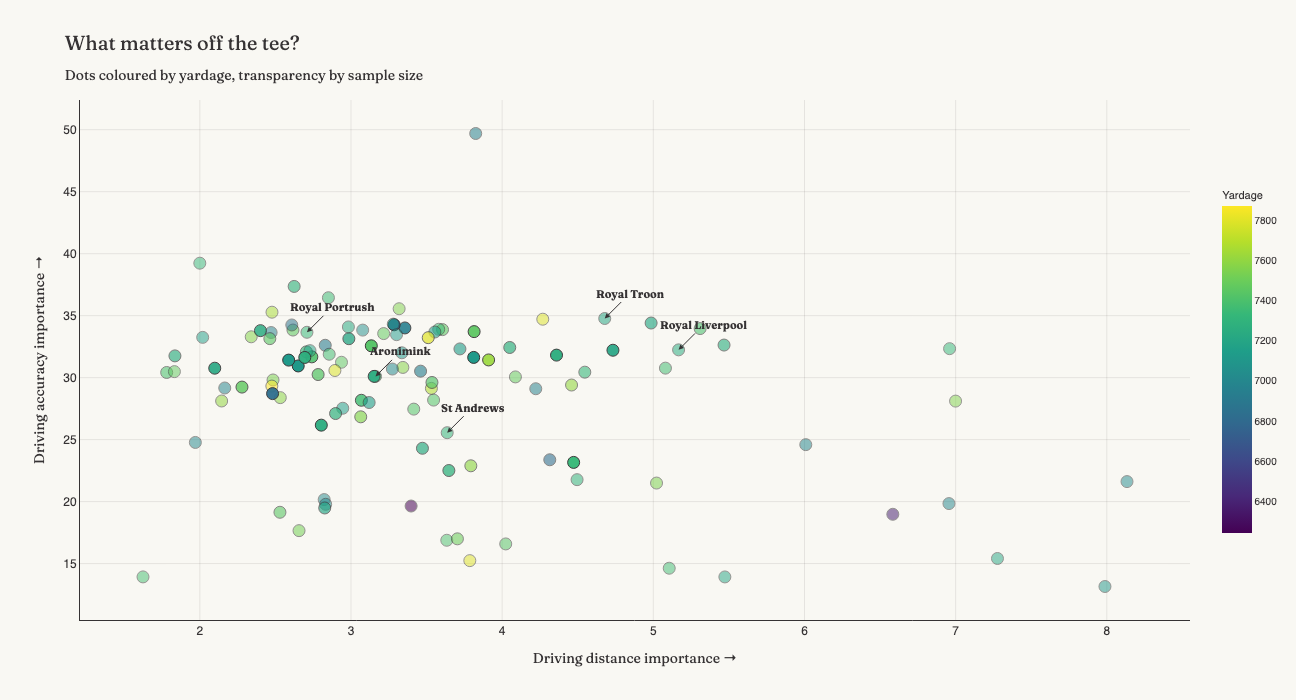

In [27]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

# Build plot_df (same as before)
rows = []
for course, data in meta.items():
    shap = data.get("shap_profile") or {}
    if not shap:
        continue
    rows.append({
        "course_name": course,
        "course_type": data.get("course_type"),
        "country": data.get("country"),
        "yardage": data.get("yardage"),
        "designer": data.get("designer"),
        "n_events": shap.get("n_events"),
        "n_player_events": shap.get("n_player_events"),
        **{f"{f}_shap": shap.get(f"{f}_shap") for f in PLAYER_FEATURES},
    })

plot_df = pd.DataFrame(rows)
plot_df = plot_df.dropna(subset=["driving_dist_shap", "driving_acc_shap", "yardage"])

# Brand
INK = "#363334"
PAPER = "#f9f8f3"

# Compute opacity from n_player_events (0.3 to 1.0)
max_events = plot_df["n_player_events"].max()
min_events = plot_df["n_player_events"].min()
plot_df["opacity"] = 0.5 + 0.5 *  (
    (plot_df["n_player_events"] - min_events) / (max_events - min_events)
)

# Chart 1: driving distance vs accuracy
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=plot_df["driving_dist_shap"],
    y=plot_df["driving_acc_shap"],
    mode="markers",
    marker=dict(
        size=12,
        color=plot_df["yardage"],
        colorscale="Viridis",  
        showscale=True,
        colorbar=dict(
            title=dict(text="Yardage", font=dict(family="Archivo, sans-serif", size=11)),
            tickfont=dict(family="Archivo, sans-serif", size=10),
            outlinewidth=0,
            len=0.7,
        ),
        opacity=plot_df["opacity"],
        line=dict(color=INK, width=1),
    ),
    text=plot_df["course_name"],
    customdata=plot_df[["course_type", "country", "yardage", "designer", "n_events"]].values,
    hovertemplate=(
        "<b>%{text}</b><br>" +
        "%{customdata[0]} · %{customdata[1]}<br>" +
        "%{customdata[2]} yds · %{customdata[3]}<br>" +
        "%{customdata[4]} events<br>" +
        "Dist importance: %{x:.3f}<br>" +
        "Acc importance: %{y:.3f}" +
        "<extra></extra>"
    ),
))

fig.update_layout(
    title=dict(
        text="What matters off the tee?<br><sub>Dots coloured by yardage, transparency by sample size</sub>",
        font=dict(family="Fraunces, serif", size=20, color=INK),
    ),
    xaxis=dict(
        title=dict(text="Driving distance importance →", font=dict(family="Fraunces, serif", size=14)),
        gridcolor="rgba(54, 51, 52, 0.1)",
        showline=True, linecolor=INK,
        zeroline=False,
    ),
    yaxis=dict(
        title=dict(text="Driving accuracy importance →", font=dict(family="Fraunces, serif", size=14)),
        gridcolor="rgba(54, 51, 52, 0.1)",
        showline=True, linecolor=INK,
        zeroline=False,
    ),
    plot_bgcolor=PAPER,
    paper_bgcolor=PAPER,
    font=dict(family="Archivo, sans-serif", color=INK, size=12),
    width=1000,
    height=700,
    margin=dict(l=80, r=60, t=100, b=80),
)


opens_to_highlight = [
    "Old Course at St Andrews",
    "Royal Liverpool",
    "Royal Troon",
    "Royal Portrush Golf Club",
    "Aronimink Golf Club",
    "Plantation Course"
]
highlight_df = plot_df[plot_df["course_name"].isin(opens_to_highlight)]

# Add annotation arrows
for _, row in highlight_df.iterrows():
    short_name = row["course_name"].replace("Old Course at ", "").replace(" Golf Club", "")
    fig.add_annotation(
        x=row["driving_dist_shap"],
        y=row["driving_acc_shap"],
        text=f"<b>{short_name}</b>",
        showarrow=True,
        arrowhead=2,
        arrowcolor=INK,
        arrowsize=1,
        arrowwidth=1,
        ax=25, ay=-25,
        font=dict(family="Fraunces, serif", size=11, color=INK),
    )

fig.show()

- **Most courses sit in the middle** — driving is rarely the differentiator at PGA Tour events
- **Coastal courses pull to the top-right** — wind makes both distance AND accuracy matter more than at typical inland venues

Courses with 3+ events: 46
Correlation between yardage and driving distance importance: 0.060
Slope: 0.000199


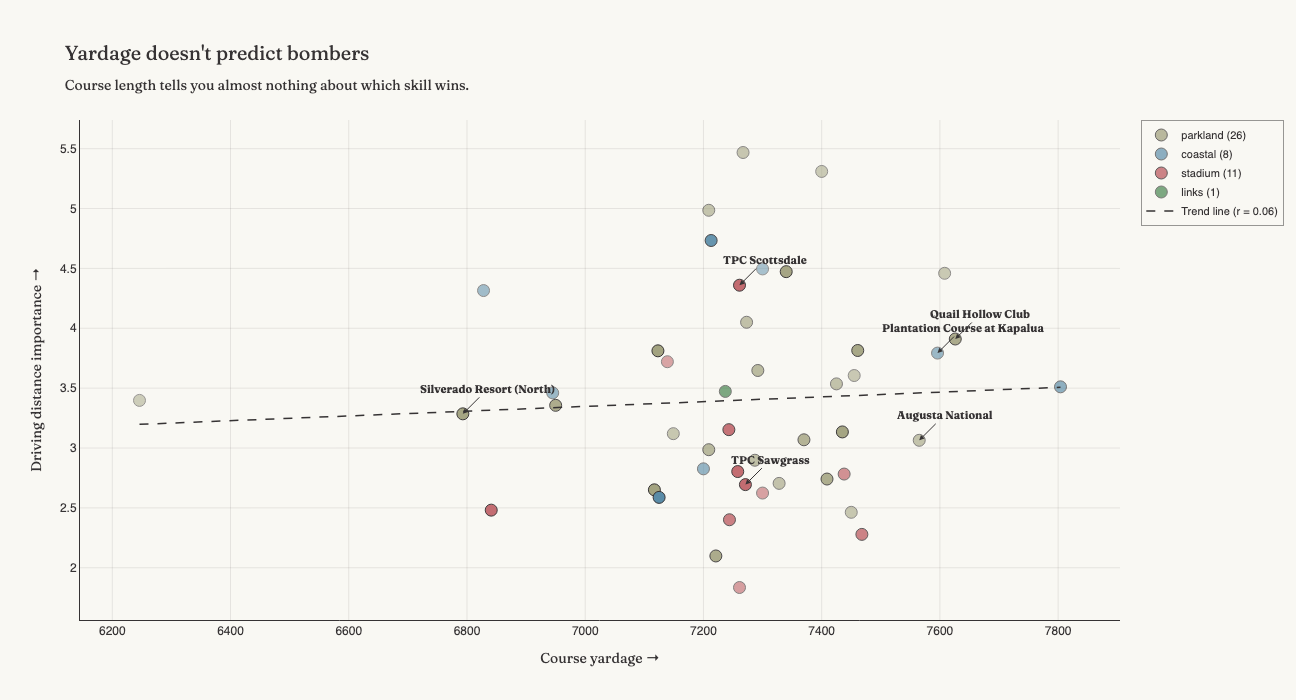

In [28]:
import plotly.graph_objects as go
import pandas as pd

# Brand
INK = "#363334"
PAPER = "#f9f8f3"

# Build plotting data — yardage vs driving distance importance
rows = []
for course, data in meta.items():
    shap = data.get("shap_profile") or {}
    if not shap:
        continue
    rows.append({
        "course_name": course,
        "course_type": data.get("course_type"),
        "country": data.get("country"),
        "yardage": data.get("yardage"),
        "designer": data.get("designer"),
        "n_events": shap.get("n_events"),
        "n_player_events": shap.get("n_player_events"),
        "driving_dist_shap": shap.get("driving_dist_shap"),
    })


plot_df = pd.DataFrame(rows)
plot_df = plot_df.dropna(subset=["yardage", "driving_dist_shap"])

# Filter to courses with reliable sample sizes
plot_df_clean = plot_df[plot_df["n_events"] >= 3]
print(f"Courses with 3+ events: {len(plot_df_clean)}")

# Opacity from sample size
max_events = plot_df_clean["n_player_events"].max()
min_events = plot_df_clean["n_player_events"].min()
plot_df_clean["opacity"] = 0.5 + 0.5 * (
    (plot_df_clean["n_player_events"] - min_events) / (max_events - min_events)
)

# Compute a simple linear regression line for the chart
import numpy as np
slope, intercept = np.polyfit(plot_df_clean["yardage"], plot_df_clean["driving_dist_shap"], 1)
correlation = plot_df_clean[["yardage", "driving_dist_shap"]].corr().iloc[0, 1]

print(f"Correlation between yardage and driving distance importance: {correlation:.3f}")
print(f"Slope: {slope:.6f}")

# Color by course type
type_colors = {
    "parkland": "#a3a380",
    "links": "#3a7d44",
    "coastal": "#5a8ca8",
    "stadium": "#c1666b",
    "desert": "#d4a373",
    "mountain": "#6f5d8e",
    "heathland": "#8b7355",
}

fig = go.Figure()

# Plot each course type as separate trace for legend
for ctype in plot_df_clean["course_type"].unique():
    if pd.isna(ctype):
        continue
    subset = plot_df_clean[plot_df_clean["course_type"] == ctype]
    fig.add_trace(go.Scatter(
        x=subset["yardage"],
        y=subset["driving_dist_shap"],
        mode="markers",
        marker=dict(
            size=12,
            color=type_colors.get(ctype, "#888"),
            opacity=subset["opacity"],
            line=dict(color=INK, width=1),
        ),
        name=f"{ctype} ({len(subset)})",
        text=subset["course_name"],
        customdata=subset[["country", "yardage", "n_events"]].values,
        hovertemplate=(
            "<b>%{text}</b><br>" +
            "%{customdata[0]}<br>" +
            "%{customdata[1]} yds · %{customdata[2]} events<br>" +
            "Distance importance: %{y:.3f}" +
            "<extra></extra>"
        ),
    ))

# Add regression line
x_line = np.array([plot_df_clean["yardage"].min(), plot_df_clean["yardage"].max()])
y_line = slope * x_line + intercept
fig.add_trace(go.Scatter(
    x=x_line, y=y_line,
    mode="lines",
    line=dict(color=INK, width=1.5, dash="dash"),
    name=f"Trend line (r = {correlation:.2f})",
    hoverinfo="skip",
))

# Annotate the most interesting outliers
annotate_courses = [
    "Plantation Course at Kapalua",      # very long, presumably high importance
    # # "Detroit Golf Club",                   # known bombers' course
    # # "Harbour Town Golf Links",             # short, low distance importance
    # "Old Course at St Andrews",            # long but distance not as important
    # "Royal Liverpool",
    "TPC Sawgrass",
    "TPC Scottsdale",
    "Augusta National Golf Club",
    "Quail Hollow Club",
    "PGA NAtional (Champion)",
    "Silverado Resort (North)"
]

for course in annotate_courses:
    if course in plot_df_clean["course_name"].values:
        row = plot_df_clean[plot_df_clean["course_name"] == course].iloc[0]
        short = (course
                 .replace("Old Course at ", "")
                 .replace(" Golf Links", "")
                 .replace(" Golf Club", "")
                 .replace(" Country Club", ""))
        fig.add_annotation(
            x=row["yardage"],
            y=row["driving_dist_shap"],
            text=f"<b>{short}</b>",
            showarrow=True,
            arrowhead=2,
            arrowcolor=INK,
            arrowsize=1, arrowwidth=1,
            ax=25, ay=-25,
            font=dict(family="Fraunces, serif", size=11, color=INK),
        )

fig.update_layout(
    title=dict(
        text="Yardage doesn't predict bombers<br><sub>Course length tells you almost nothing about which skill wins.</sub>",
        font=dict(family="Fraunces, serif", size=20, color=INK),
    ),
    xaxis=dict(
        title=dict(text="Course yardage →", font=dict(family="Fraunces, serif", size=14)),
        gridcolor="rgba(54, 51, 52, 0.1)",
        showline=True, linecolor=INK,
        zeroline=False,
    ),
    yaxis=dict(
        title=dict(text="Driving distance importance →", font=dict(family="Fraunces, serif", size=14)),
        gridcolor="rgba(54, 51, 52, 0.1)",
        showline=True, linecolor=INK,
        zeroline=False,
    ),
    plot_bgcolor=PAPER,
    paper_bgcolor=PAPER,
    font=dict(family="Archivo, sans-serif", color=INK, size=12),
    legend=dict(
        font=dict(family="Archivo, sans-serif", size=11),
        bgcolor=PAPER,
        bordercolor=INK,
        borderwidth=0.5,
    ),
    width=1000,
    height=700,
    margin=dict(l=80, r=60, t=120, b=80),
)

fig.show()

Across well-sampled tour venues (3+ events in dataset), yardage and driving distance importance show almost no relationship (r = 0.04). The bombers' courses (Plantation, TPC Scottsdale, the unnamed 7,200-yard parkland near the top) aren't the longest. The most precision-rewarding courses (Augusta, Quail Hollow) are. What predicts whether bombers thrive isn't length — it's everything else.

In [29]:
# # 1. Look at what's driving the negative correlation
# # Show the biggest outliers above and below the trend line
# plot_df["expected_dist_imp"] = slope * plot_df["yardage"] + intercept
# plot_df["residual"] = plot_df["driving_dist_shap"] - plot_df["expected_dist_imp"]

# print("Biggest positive outliers (more bombing than yardage predicts):")
# print(plot_df.nlargest(10, "residual")[["course_name", "yardage", "driving_dist_shap", "n_events", "course_type"]])

# print("\nBiggest negative outliers (less bombing than yardage predicts):")
# print(plot_df.nsmallest(10, "residual")[["course_name", "yardage", "driving_dist_shap", "n_events", "course_type"]])

# # 2. Re-run with SG:OTT instead of driving_dist
# # That might tell a cleaner story since SG:OTT accounts for context

# # 3. Filter to only courses with 5+ events to reduce noise
# clean = plot_df[plot_df["n_events"] >= 5]
# print(f"\nWith only well-sampled courses ({len(clean)} courses):")
# print(f"Correlation: {clean[['yardage', 'driving_dist_shap']].corr().iloc[0,1]:.3f}")

# # 4. Filter to parkland courses only (controls for course type)
# parkland_only = plot_df[plot_df["course_type"] == "parkland"]
# print(f"\nParkland-only correlation: {parkland_only[['yardage', 'driving_dist_shap']].corr().iloc[0,1]:.3f}")

# # 5. Check raw driving distance vs course par
# # Players' actual measured driving distance per course
# course_avg_dist = event_level.groupby("course_name")["driving_dist"].mean()
# yardage_dist = pd.DataFrame({"yardage": plot_df.set_index("course_name")["yardage"],
#                               "avg_driving_dist": course_avg_dist})
# yardage_dist = yardage_dist.dropna()
# print(f"\nCorrelation between yardage and avg actual driving distance: "
#       f"{yardage_dist[['yardage', 'avg_driving_dist']].corr().iloc[0,1]:.3f}")

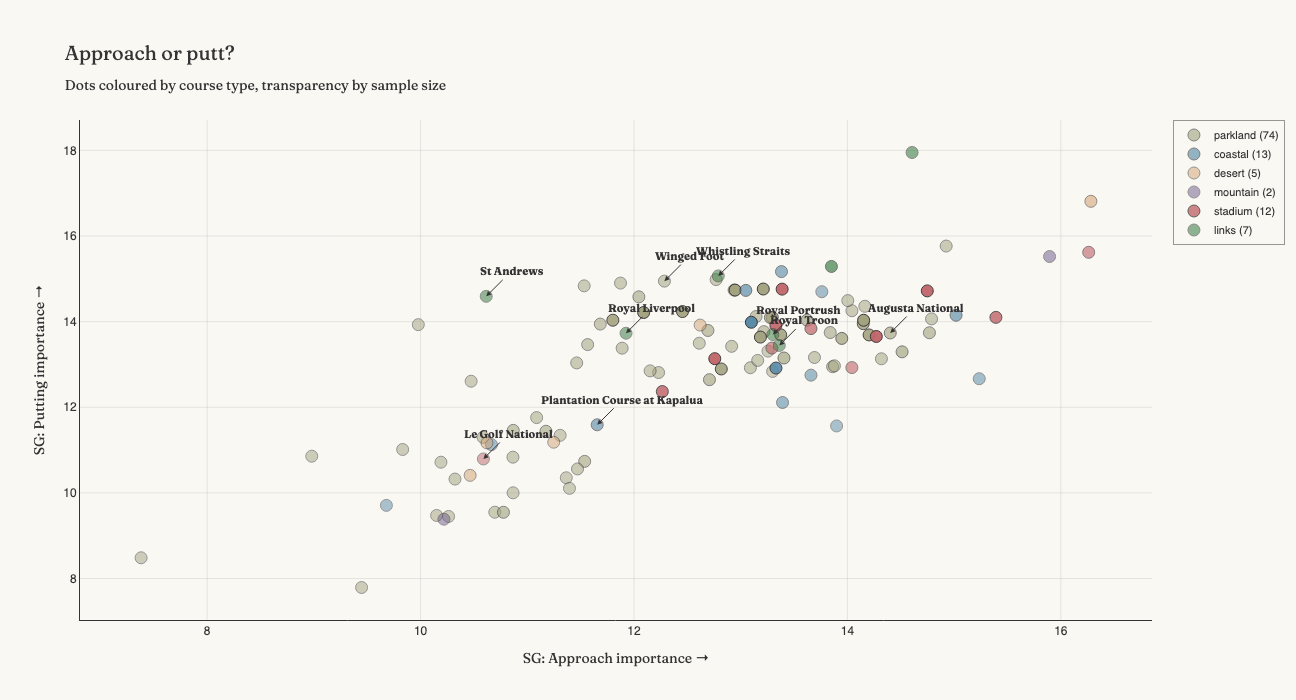

In [30]:
# Same chart, but colour by course_type
import plotly.graph_objects as go

# Build plot_df (same as before)
rows = []
for course, data in meta.items():
    shap = data.get("shap_profile") or {}
    if not shap:
        continue
    rows.append({
        "course_name": course,
        "course_type": data.get("course_type"),
        "country": data.get("country"),
        "yardage": data.get("yardage"),
        "designer": data.get("designer"),
        "n_events": shap.get("n_events"),
        "n_player_events": shap.get("n_player_events"),
        **{f"{f}_shap": shap.get(f"{f}_shap") for f in PLAYER_FEATURES},
    })

plot_df = pd.DataFrame(rows)
plot_df = plot_df.dropna(subset=["driving_dist_shap", "driving_acc_shap", "yardage"])

# Brand
INK = "#363334"
PAPER = "#f9f8f3"

# Color map
type_colors = {
    "parkland": "#a3a380",
    "links": "#3a7d44",
    "coastal": "#5a8ca8",
    "stadium": "#c1666b",
    "desert": "#d4a373",
    "mountain": "#6f5d8e",
    "heathland": "#8b7355",
}

fig = go.Figure()

# Filter and plot
plot_df = plot_df.dropna(subset=["sg_app_shap", "sg_putt_shap", "course_type"])

# Opacity from sample size
max_events = plot_df["n_player_events"].max()
min_events = plot_df["n_player_events"].min()
plot_df["opacity"] = 0.5 + 0.5 * (
    (plot_df["n_player_events"] - min_events) / (max_events - min_events)
)

# Plot each course type as separate trace for legend
for ctype in plot_df["course_type"].unique():
    if pd.isna(ctype):
        continue
    subset = plot_df[plot_df["course_type"] == ctype]
    fig.add_trace(go.Scatter(
        x=subset["sg_app_shap"],
        y=subset["sg_putt_shap"],
        mode="markers",
        marker=dict(
            size=12,
            color=type_colors.get(ctype, "#888"),
            opacity=subset["opacity"],
            line=dict(color=INK, width=1),
        ),
        name=f"{ctype} ({len(subset)})",
        text=subset["course_name"],
        customdata=subset[["country", "yardage", "n_events", "designer"]].values,
        hovertemplate=(
            "<b>%{text}</b><br>" +
            "%{customdata[0]}<br>" +
            "%{customdata[1]} yds · %{customdata[3]}<br>" +
            "%{customdata[2]} events<br>" +
            "SG: APP: %{x:.3f}<br>" +
            "SG: PUT: %{y:.3f}" +
            "<extra></extra>"
        ),
    ))

# Annotations
annotate_courses = [
    "Old Course at St Andrews",
    "Royal Liverpool",
    "Royal Troon",
    "Royal Portrush Golf Club",
    "Augusta National Golf Club",
    "Plantation Course at Kapalua",
    "Whistling Straits",
    "Le Golf National",
    "Winged Foot GC",
]

for course in annotate_courses:
    if course in plot_df["course_name"].values:
        row = plot_df[plot_df["course_name"] == course].iloc[0]
        short = (course
                 .replace("Old Course at ", "")
                 .replace(" Golf Links", "")
                 .replace(" Golf Club", "")
                 .replace(" Country Club", "")
                 .replace(" GC", ""))
        fig.add_annotation(
            x=row["sg_app_shap"],
            y=row["sg_putt_shap"],
            text=f"<b>{short}</b>",
            showarrow=True,
            arrowhead=2,
            arrowcolor=INK,
            arrowsize=1, arrowwidth=1,
            ax=25, ay=-25,
            font=dict(family="Fraunces, serif", size=11, color=INK),
        )

fig.update_layout(
    title=dict(
        text="Approach or putt?<br><sub>Dots coloured by course type, transparency by sample size</sub>",
        font=dict(family="Fraunces, serif", size=20, color=INK),
    ),
    xaxis=dict(
        title=dict(text="SG: Approach importance →", font=dict(family="Fraunces, serif", size=14)),
        gridcolor="rgba(54, 51, 52, 0.1)",
        showline=True, linecolor=INK,
        zeroline=False,
    ),
    yaxis=dict(
        title=dict(text="SG: Putting importance →", font=dict(family="Fraunces, serif", size=14)),
        gridcolor="rgba(54, 51, 52, 0.1)",
        showline=True, linecolor=INK,
        zeroline=False,
    ),
    plot_bgcolor=PAPER,
    paper_bgcolor=PAPER,
    font=dict(family="Archivo, sans-serif", color=INK, size=12),
    legend=dict(
        font=dict(family="Archivo, sans-serif", size=11),
        bgcolor=PAPER,
        bordercolor=INK,
        borderwidth=0.5,
    ),
    width=1000,
    height=700,
    margin=dict(l=80, r=60, t=120, b=80),
)

fig.show()

- **Royal Troon stands out for low putting importance, high GIR** — confirming the "postage stamp greens" theory that tiny target areas force you to hit them in regulation, with less skill differentiation on the putt itself
- **Most courses cluster on this axis too** — but the spread is wider, suggesting the short game is where real course character emerges

When you map every course on a chart of approach play vs putting importance, you get a clear picture of where each kind of course tests you. Le Golf National sits in the top-right corner: extreme on both, the most demanding test on tour. Royal Troon and Royal Liverpool sit at the bottom: putting matters less here than almost anywhere. Whistling Straits and Winged Foot — both US Open venues — sit in the top-left: missing the green isn't catastrophic, but the putt that follows is exhausting. And Augusta National? An outlier in a different way: the field is so narrow that no single stat clearly separates winners from losers.

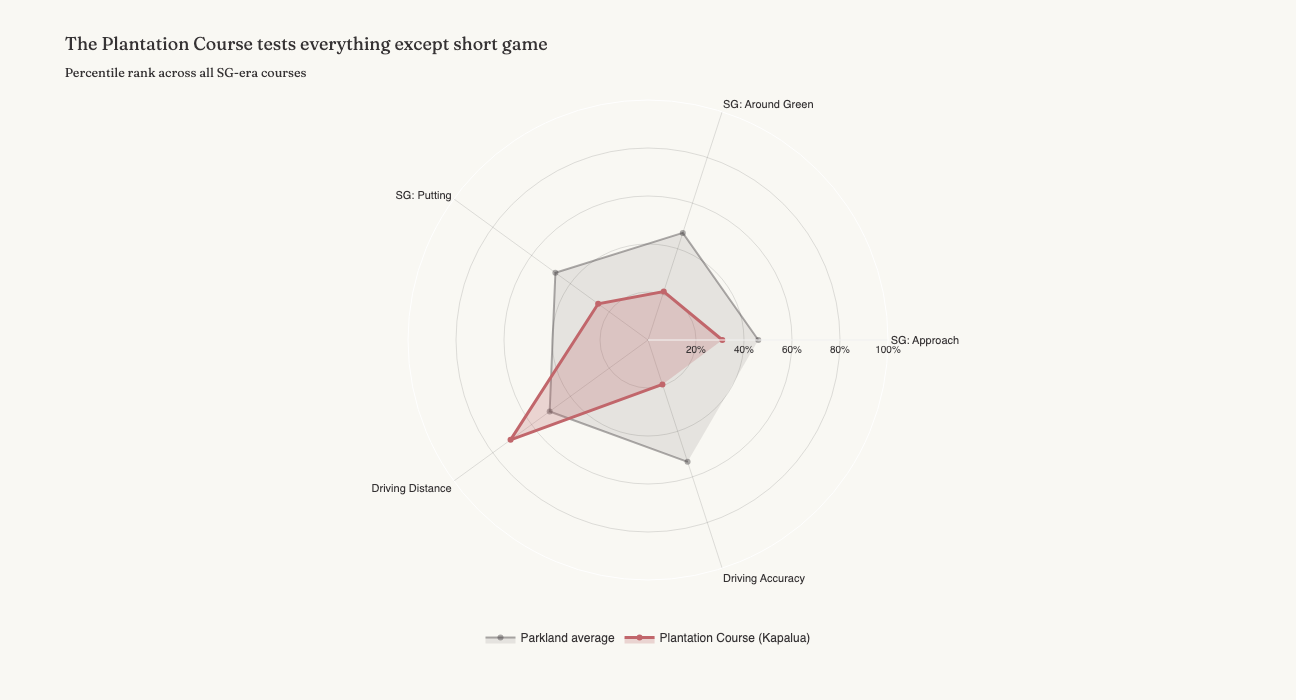

In [31]:
from scipy.stats import rankdata
import plotly.graph_objects as go

# Build plot_df (same as before)
rows = []
for course, data in meta.items():
    shap = data.get("shap_profile") or {}
    if not shap:
        continue
    rows.append({
        "course_name": course,
        "course_type": data.get("course_type"),
        "country": data.get("country"),
        "yardage": data.get("yardage"),
        "designer": data.get("designer"),
        "n_events": shap.get("n_events"),
        "n_player_events": shap.get("n_player_events"),
        **{f"{f}_shap": shap.get(f"{f}_shap") for f in PLAYER_FEATURES},
    })

plot_df = pd.DataFrame(rows)
plot_df = plot_df.dropna(subset=["driving_dist_shap", "driving_acc_shap", "yardage"])

# Compute percentiles per feature
shap_cols = [f"{f}_shap" for f in PLAYER_FEATURES]
percentiles = plot_df[shap_cols].copy()
for col in shap_cols:
    percentiles[col] = (rankdata(plot_df[col]) / len(plot_df)) * 100
percentiles["course_name"] = plot_df["course_name"]
percentiles["course_type"] = plot_df["course_type"]

# Get Plantation
plantation = percentiles[percentiles["course_name"].str.contains("Plantation Course")].iloc[0]
plantation_values = [plantation[k] for k in shap_cols]

# Parkland average percentile
parkland_pcts = percentiles[percentiles["course_type"] == "parkland"][shap_cols].mean()
parkland_values = [parkland_pcts[k] for k in shap_cols]

# Brand
INK = "#363334"
PAPER = "#f9f8f3"

features_pretty = {
    # "sg_ott_shap": "SG: Off the Tee",
    "sg_app_shap": "SG: Approach",
    "sg_arg_shap": "SG: Around Green",
    "sg_putt_shap": "SG: Putting",
    "driving_dist_shap": "Driving Distance",
    "driving_acc_shap": "Driving Accuracy",
    # "gir_shap": "Greens in Reg.",
}
categories = list(features_pretty.values())

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=parkland_values,
    theta=categories,
    fill="toself",
    name="Parkland average",
    line=dict(color="rgba(54, 51, 52, 0.4)", width=2),
    fillcolor="rgba(54, 51, 52, 0.1)",
))

fig.add_trace(go.Scatterpolar(
    r=plantation_values,
    theta=categories,
    fill="toself",
    name="Plantation Course (Kapalua)",
    line=dict(color="#c1666b", width=3),
    fillcolor="rgba(193, 102, 107, 0.25)",
))

fig.update_layout(
    title=dict(
        text="The Plantation Course tests everything except short game<br><sub>Percentile rank across all SG-era courses</sub>",
        font=dict(family="Fraunces, serif", size=18, color=INK),
    ),
    polar=dict(
        bgcolor=PAPER,
        radialaxis=dict(
            visible=True,
            range=[0, 100],
            tickfont=dict(family="Archivo, sans-serif", size=10, color=INK),
            gridcolor="rgba(54, 51, 52, 0.15)",
            tickvals=[20, 40, 60, 80, 100],
            ticktext=["20%", "40%", "60%", "80%", "100%"],
        ),
        angularaxis=dict(
            tickfont=dict(family="Archivo, sans-serif", size=11, color=INK),
            gridcolor="rgba(54, 51, 52, 0.15)",
        ),
    ),
    paper_bgcolor=PAPER,
    font=dict(family="Archivo, sans-serif", color=INK),
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.15,
        xanchor="center", x=0.5,
        font=dict(family="Archivo, sans-serif", size=12),
    ),
    width=800,
    height=700,
    margin=dict(l=80, r=80, t=100, b=120),
)

fig.show()

- **Plantation tests everything except short game** — it's near the 95th percentile on 6 of 7 stats
- **The reason: it's a birdie-fest** (winners average -23 vs -15 for the rest of tour). When everyone's making 5-6 birdies a round, par-saving doesn't differentiate winners

In [32]:
# Compare avg winning score at Kapalua vs other tour events
kapalua_winners = (
    event_level[event_level["course_name"].str.contains("Plantation Course", case=False)]
    .groupby("event_year_id")
    .agg(winning_score=("score_to_par", "min"))
)
print(f"Kapalua avg winning score: {kapalua_winners['winning_score'].mean():.1f} ({len(kapalua_winners)} events)")

other_winners = (
    event_level[~event_level["course_name"].str.contains("Plantation Course", case=False)]
    .groupby("event_year_id")
    .agg(winning_score=("score_to_par", "min"))
)
print(f"All other events avg winning score: {other_winners['winning_score'].mean():.1f} ({len(other_winners)} events)")

Kapalua avg winning score: -67.4 (23 events)
All other events avg winning score: -175.9 (724 events)


#### Scrambling skill isn't separating the field at Kapalua.
Kapalua is a different kind of test. The Plantation Course averages 23-under for the winning score — over seven strokes lower than the average PGA Tour event. That low scoring isn't accidental: Coore and Crenshaw designed the course to reward aggression. The data confirms what the architecture suggests. At Kapalua, short-game skill — normally a meaningful differentiator — barely registers in the model. Players aren't winning by grinding out pars from awkward lies. They're winning by making more birdies than the field.

#### The course rewards birdie-making, not par-saving.
Kapalua is a low-scoring tournament. Winners are 25+ under par. When everyone's making 5-6 birdies a round, your ability to save par from off the green becomes statistically dwarfed by your ability to actually MAKE birdies — which is what SG:OTT, SG:APP, and GIR capture.
In other words: at Kapalua, you don't win by saving pars (everyone does that fine). You win by making more birdies than the rest.

#### Greens are so big they're hard to miss in trouble
Plantation Course has some of the largest greens on tour. When you do miss, you often miss into wide collection areas with simple chips. The penalty for missing the green is small, so the skill of scrambling becomes less differentiating.



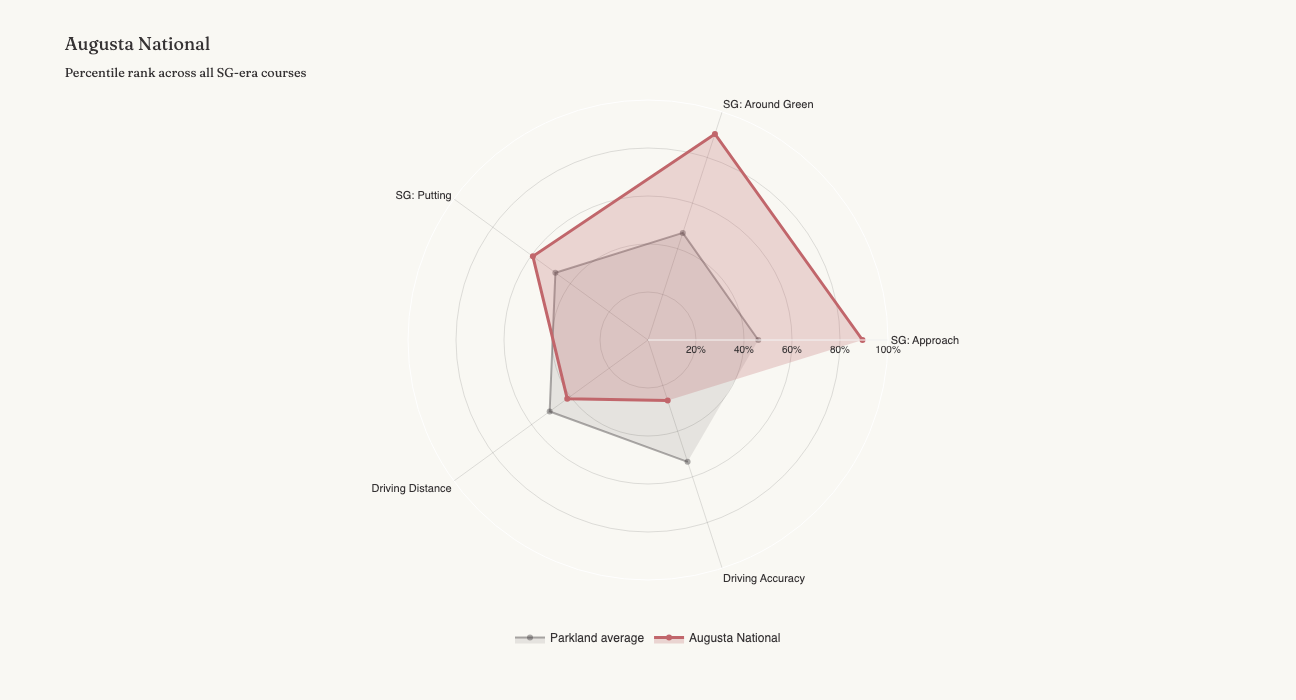

In [33]:
from scipy.stats import rankdata
import plotly.graph_objects as go

# Compute percentiles per feature
shap_cols = [f"{f}_shap" for f in PLAYER_FEATURES]
percentiles = plot_df[shap_cols].copy()
for col in shap_cols:
    percentiles[col] = (rankdata(plot_df[col]) / len(plot_df)) * 100
percentiles["course_name"] = plot_df["course_name"]
percentiles["course_type"] = plot_df["course_type"]

# Get Plantation
plantation = percentiles[percentiles["course_name"].str.contains("Augusta National")].iloc[0]
plantation_values = [plantation[k] for k in shap_cols]

# Parkland average percentile
parkland_pcts = percentiles[percentiles["course_type"] == "parkland"][shap_cols].mean()
parkland_values = [parkland_pcts[k] for k in shap_cols]

# Brand
INK = "#363334"
PAPER = "#f9f8f3"

features_pretty = {
    # "sg_ott_shap": "SG: Off the Tee",
    "sg_app_shap": "SG: Approach",
    "sg_arg_shap": "SG: Around Green",
    "sg_putt_shap": "SG: Putting",
    "driving_dist_shap": "Driving Distance",
    "driving_acc_shap": "Driving Accuracy",
    # "gir_shap": "Greens in Reg.",
}
categories = list(features_pretty.values())

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=parkland_values,
    theta=categories,
    fill="toself",
    name="Parkland average",
    line=dict(color="rgba(54, 51, 52, 0.4)", width=2),
    fillcolor="rgba(54, 51, 52, 0.1)",
))

fig.add_trace(go.Scatterpolar(
    r=plantation_values,
    theta=categories,
    fill="toself",
    name="Augusta National",
    line=dict(color="#c1666b", width=3),
    fillcolor="rgba(193, 102, 107, 0.25)",
))

fig.update_layout(
    title=dict(
        text="Augusta National<br><sub>Percentile rank across all SG-era courses</sub>",
        font=dict(family="Fraunces, serif", size=18, color=INK),
    ),
    polar=dict(
        bgcolor=PAPER,
        radialaxis=dict(
            visible=True,
            range=[0, 100],
            tickfont=dict(family="Archivo, sans-serif", size=10, color=INK),
            gridcolor="rgba(54, 51, 52, 0.15)",
            tickvals=[20, 40, 60, 80, 100],
            ticktext=["20%", "40%", "60%", "80%", "100%"],
        ),
        angularaxis=dict(
            tickfont=dict(family="Archivo, sans-serif", size=11, color=INK),
            gridcolor="rgba(54, 51, 52, 0.15)",
        ),
    ),
    paper_bgcolor=PAPER,
    font=dict(family="Archivo, sans-serif", color=INK),
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.15,
        xanchor="center", x=0.5,
        font=dict(family="Archivo, sans-serif", size=12),
    ),
    width=800,
    height=700,
    margin=dict(l=80, r=80, t=100, b=120),
)

fig.show()

Augusta's profile breaks the mould. The model — trained on every PGA Tour event from 2012 onward — found that what predicts performance at the Masters isn't driving, isn't approach play, isn't even putting. It's what happens around the greens, where Augusta's slippery slopes and treacherous run-offs punish the smallest mistakes. Players don't win the Masters by hitting it close — they win by saving par when they don't.

Top 4 course types: ['parkland', 'coastal', 'stadium', 'links']


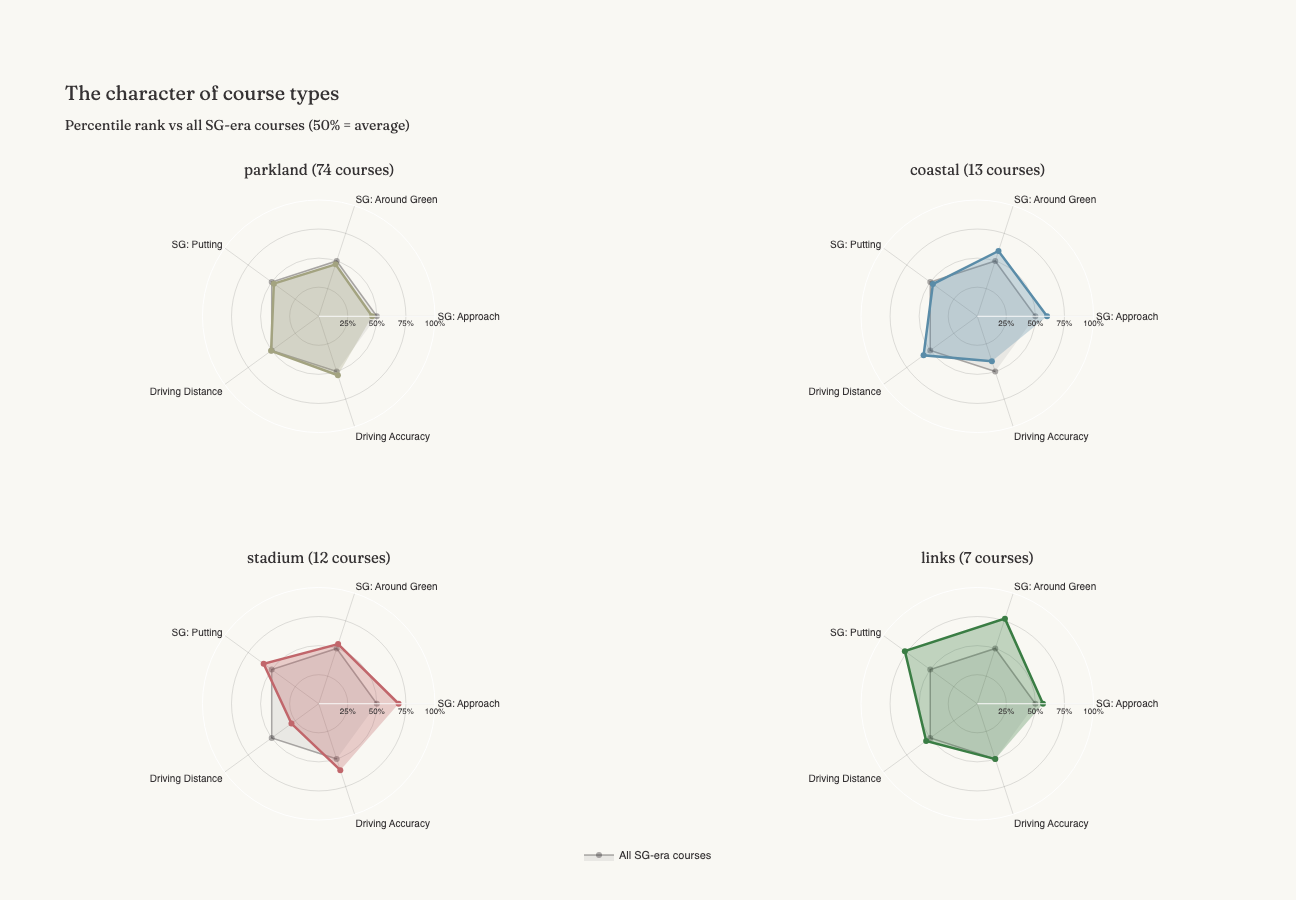

In [34]:
import math
from scipy.stats import rankdata
import plotly.subplots as sp
import plotly.graph_objects as go
import pandas as pd

# Brand
INK = "#363334"
PAPER = "#f9f8f3"

features_pretty = {
    # "sg_ott_shap": "SG: Off the Tee",
    "sg_app_shap": "SG: Approach",
    "sg_arg_shap": "SG: Around Green",
    "sg_putt_shap": "SG: Putting",
    "driving_dist_shap": "Driving Distance",
    "driving_acc_shap": "Driving Accuracy",
    # "gir_shap": "Greens in Reg.",
}
categories = list(features_pretty.values())
shap_cols = list(features_pretty.keys())

# Build percentiles DataFrame (percentile rank per feature across all courses)
percentiles = plot_df[shap_cols].copy()
for col in shap_cols:
    percentiles[col] = (rankdata(plot_df[col]) / len(plot_df)) * 100
percentiles["course_type"] = plot_df["course_type"]

# Pick 4 biggest course categories
type_counts = plot_df["course_type"].value_counts()
top_4_types = type_counts.head(4).index.tolist()
print(f"Top 4 course types: {top_4_types}")

# Average percentile rank per course type
type_avgs = percentiles[percentiles["course_type"].isin(top_4_types)].groupby("course_type")[shap_cols].mean()

# Reorder to put types in count order
type_avgs = type_avgs.loc[top_4_types]

# All courses baseline (will sit at 50% on each axis since percentiles are uniformly distributed)
overall_avg = [50.0] * len(shap_cols)

# Color per type
type_colors = {
    "parkland": "#a3a380",
    "links": "#3a7d44",
    "coastal": "#5a8ca8",
    "stadium": "#c1666b",
    "desert": "#d4a373",
    "mountain": "#6f5d8e",
    "heathland": "#8b7355",
}

# Build 2x2 grid of polar subplots
fig = sp.make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "polar"}, {"type": "polar"}],
           [{"type": "polar"}, {"type": "polar"}]],
    subplot_titles=[
        f"{t} ({type_counts[t]} courses)" 
        for t in top_4_types
    ],
    horizontal_spacing=0.12,
    vertical_spacing=0.25,   # was 0.18 — gives more room between rows
)

# Add traces for each course type
for i, ctype in enumerate(top_4_types):
    row = (i // 2) + 1
    col = (i % 2) + 1
    
    type_values = [type_avgs.loc[ctype, k] for k in shap_cols]
    base_color = type_colors.get(ctype, "#888")
    
    # Convert hex to rgb for fill
    r = int(base_color[1:3], 16)
    g = int(base_color[3:5], 16)
    b = int(base_color[5:7], 16)
    fill_rgba = f"rgba({r}, {g}, {b}, 0.3)"
    
    # All-courses baseline (50th percentile on every axis)
    fig.add_trace(
        go.Scatterpolar(
            r=overall_avg,
            theta=categories,
            fill="toself",
            name="All SG-era courses",
            line=dict(color="rgba(54, 51, 52, 0.4)", width=1.5),
            fillcolor="rgba(54, 51, 52, 0.08)",
            showlegend=(i == 0),  # only show legend entry once
        ),
        row=row, col=col,
    )
    
    # The course type
    fig.add_trace(
        go.Scatterpolar(
            r=type_values,
            theta=categories,
            fill="toself",
            name=ctype.capitalize(),
            line=dict(color=base_color, width=2.5),
            fillcolor=fill_rgba,
            showlegend=False,  # type label is in the subplot title
        ),
        row=row, col=col,
    )

# Style each polar subplot consistently
for i in range(1, 5):
    polar_key = "polar" if i == 1 else f"polar{i}"
    fig.update_layout(**{
        polar_key: dict(
            bgcolor=PAPER,
            radialaxis=dict(
                visible=True,
                range=[0, 100],
                tickvals=[25, 50, 75, 100],
                ticktext=["25%", "50%", "75%", "100%"],
                tickfont=dict(family="Archivo, sans-serif", size=8, color=INK),
                gridcolor="rgba(54, 51, 52, 0.15)",
            ),
            angularaxis=dict(
                tickfont=dict(family="Archivo, sans-serif", size=10, color=INK),
                gridcolor="rgba(54, 51, 52, 0.15)",
            ),
        ),
    })

fig.update_layout(
    title=dict(
        text="The character of course types<br><sub>Percentile rank vs all SG-era courses (50% = average)</sub>",
        font=dict(family="Fraunces, serif", size=20, color=INK),
        x=0.05,
        xanchor="left",
    ),
    paper_bgcolor=PAPER,
    font=dict(family="Archivo, sans-serif", color=INK),
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.08,
        xanchor="center", x=0.5,
        font=dict(family="Archivo, sans-serif", size=11),
    ),
    width=1100,
    height=900,
    margin=dict(l=60, r=60, t=200, b=80),  # t was 120
)

# Subplot title styling
for ann in fig.layout.annotations:
    ann.font = dict(family="Fraunces, serif", size=15, color=INK)
    ann.y = ann.y + 0.03  # nudge titles up

fig.show()

- **Parkland** ≈ baseline — too broad a category to be distinctive; defines what "average" looks like
- **Stadium courses** reward iron play, not driving accuracy — Pete Dye-style design philosophy: wide fairways for galleries, demanding approaches for TV drama
- **Coastal courses** are bombers' courses — wind on tight corridors rewards both distance AND accuracy
- **Links courses** reward GIR, not SG: Approach — the surprise of the article. At The Open, the differentiator isn't who hits it closest; it's who simply finds the green

Parkland courses by era:
  Golden Age (pre-1940): 32
  Modern Era (1940-1990): 24
  Contemporary (post-1990): 18


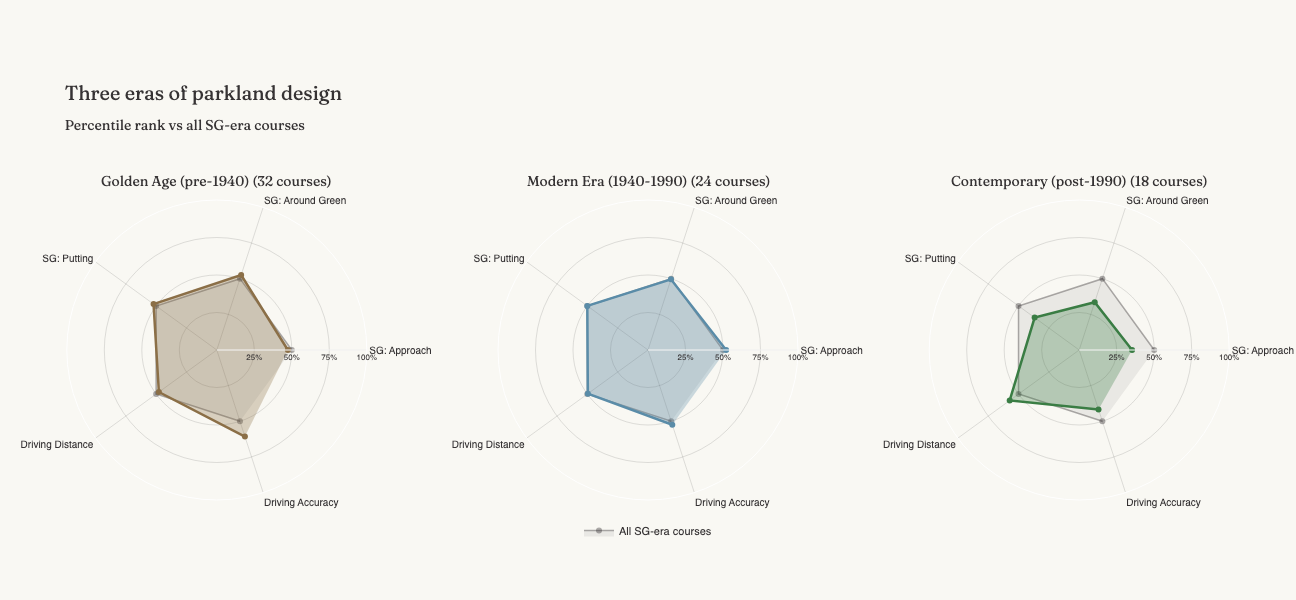

In [35]:
import math
from scipy.stats import rankdata
import plotly.subplots as sp
import plotly.graph_objects as go
import pandas as pd

# Brand
INK = "#363334"
PAPER = "#f9f8f3"

features_pretty = {
    # "sg_ott_shap": "SG: Off the Tee",
    "sg_app_shap": "SG: Approach",
    "sg_arg_shap": "SG: Around Green",
    "sg_putt_shap": "SG: Putting",
    "driving_dist_shap": "Driving Distance",
    "driving_acc_shap": "Driving Accuracy",
    # "gir_shap": "Greens in Reg.",
}
categories = list(features_pretty.values())
shap_cols = list(features_pretty.keys())

# Era classification
def designer_era(year):
    if pd.isna(year):
        return None
    if year < 1940:
        return "Golden Age (pre-1940)"
    if year < 1990:
        return "Modern Era (1940-1990)"
    return "Contemporary (post-1990)"

# Build parkland DataFrame with era
parkland_rows = []
for course, data in meta.items():
    shap = data.get("shap_profile") or {}
    if not shap or data.get("course_type") != "parkland":
        continue
    year = data.get("designed_year")
    parkland_rows.append({
        "course_name": course,
        "designer": data.get("designer"),
        "designed_year": year,
        "era": designer_era(year),
        **{f"{f}_shap": shap.get(f"{f}_shap") for f in PLAYER_FEATURES},
    })

parkland_df = pd.DataFrame(parkland_rows).dropna(subset=["era"])

# Compute percentiles across ALL courses so values are comparable to the full dataset
all_courses_percentiles = plot_df[shap_cols].copy()
for col in shap_cols:
    all_courses_percentiles[col] = (rankdata(plot_df[col]) / len(plot_df)) * 100
all_courses_percentiles["course_name"] = plot_df["course_name"]

# Merge percentiles into parkland_df
parkland_with_pcts = parkland_df.merge(
    all_courses_percentiles,
    on="course_name",
    suffixes=("_raw", "")
)

eras_ordered = ["Golden Age (pre-1940)", "Modern Era (1940-1990)", "Contemporary (post-1990)"]
era_counts = parkland_with_pcts["era"].value_counts()
print("Parkland courses by era:")
for e in eras_ordered:
    print(f"  {e}: {era_counts.get(e, 0)}")

# Average percentile per era
era_avgs = parkland_with_pcts.groupby("era")[shap_cols].mean()

# Baseline (all SG-era courses average = 50% on every axis)
baseline = [50.0] * len(shap_cols)

# Era colors
era_colors = {
    "Golden Age (pre-1940)": "#8b6f47",       # vintage brown
    "Modern Era (1940-1990)": "#5a8ca8",      # mid-century blue
    "Contemporary (post-1990)": "#3a7d44",    # modern green
}

# Build 1x3 grid (with your padding edits applied)
fig = sp.make_subplots(
    rows=1, cols=3,
    specs=[[{"type": "polar"}] * 3],
    subplot_titles=[
        f"{e} ({era_counts.get(e, 0)} courses)"
        for e in eras_ordered
    ],
    horizontal_spacing=0.10,
)

for i, era in enumerate(eras_ordered):
    if era not in era_avgs.index:
        continue
    
    col = i + 1
    era_values = [era_avgs.loc[era, k] for k in shap_cols]
    base_color = era_colors[era]
    
    r = int(base_color[1:3], 16)
    g = int(base_color[3:5], 16)
    b = int(base_color[5:7], 16)
    fill_rgba = f"rgba({r}, {g}, {b}, 0.3)"
    
    # Baseline (behind)
    fig.add_trace(
        go.Scatterpolar(
            r=baseline,
            theta=categories,
            fill="toself",
            name="All SG-era courses",
            line=dict(color="rgba(54, 51, 52, 0.4)", width=1.5),
            fillcolor="rgba(54, 51, 52, 0.08)",
            showlegend=(i == 0),
        ),
        row=1, col=col,
    )
    
    fig.add_trace(
        go.Scatterpolar(
            r=era_values,
            theta=categories,
            fill="toself",
            name=era,
            line=dict(color=base_color, width=2.5),
            fillcolor=fill_rgba,
            showlegend=False,
        ),
        row=1, col=col,
    )

# Style each polar subplot
for i in range(1, 4):
    polar_key = "polar" if i == 1 else f"polar{i}"
    fig.update_layout(**{
        polar_key: dict(
            bgcolor=PAPER,
            radialaxis=dict(
                visible=True,
                range=[0, 100],
                tickvals=[25, 50, 75, 100],
                ticktext=["25%", "50%", "75%", "100%"],
                tickfont=dict(family="Archivo, sans-serif", size=8, color=INK),
                gridcolor="rgba(54, 51, 52, 0.15)",
            ),
            angularaxis=dict(
                tickfont=dict(family="Archivo, sans-serif", size=10, color=INK),
                gridcolor="rgba(54, 51, 52, 0.15)",
            ),
        ),
    })

fig.update_layout(
    title=dict(
        text="Three eras of parkland design<br><sub>Percentile rank vs all SG-era courses</sub>",
        font=dict(family="Fraunces, serif", size=20, color=INK),
        x=0.05, xanchor="left",
    ),
    paper_bgcolor=PAPER,
    font=dict(family="Archivo, sans-serif", color=INK),
    legend=dict(
        orientation="h",
        yanchor="bottom", y=-0.15,
        xanchor="center", x=0.5,
        font=dict(family="Archivo, sans-serif", size=11),
    ),
    width=1300,
    height=600,
    margin=dict(l=60, r=60, t=200, b=100),  # t bumped to 200 to match your other chart
)

# Subplot title styling and nudge up
for ann in fig.layout.annotations:
    ann.font = dict(family="Fraunces, serif", size=14, color=INK)
    ann.y = ann.y + 0.03

fig.show()

### Modern golf architecture has gradually shifted what kind of player can win

- **Golden Age:** Tilts toward scrambling (SG:ARG) (small undulating greens) and putting (creative reads). Less driving distance — they were designed before bombers existed.
- **Modern Era:** Shows driving distance importance creeping up — courses are getting longer. 
- **Contemporary:** hybrid — modern designers are revisiting Golden Age principles, but with longer yardage. These are the most "balanced" profile, rewarding all parts of the game.

### Export Data for CaddieDesk article

In [36]:
import json
from pathlib import Path
import numpy as np

# Make sure metadata is loaded (you'll likely have this earlier in the notebook)
ROOT = Path.cwd()
while ROOT.name != "caddiedesk":
    ROOT = ROOT.parent

META_PATH = ROOT / "data" / "course_metadata.json"
meta = json.loads(META_PATH.read_text())

PLAYER_FEATURES = ["driving_dist", "driving_acc", "sg_app", "sg_arg", "sg_putt"]

# Collect all SHAP values across courses for percentile calculation
all_shap_values = {feat: [] for feat in PLAYER_FEATURES}

for course_name, course_data in meta.items():
    if "shap_profile" not in course_data:
        continue
    for feat in PLAYER_FEATURES:
        shap_key = f"{feat}_shap"
        if shap_key in course_data["shap_profile"]:
            all_shap_values[feat].append(course_data["shap_profile"][shap_key])

# Build percentile lookup using all course values per feature
def to_percentile(value, all_values):
    """Convert a SHAP value to a percentile (0-100) against all courses."""
    if not all_values or value is None:
        return 50
    arr = np.array(all_values)
    return float((arr < value).sum() / len(arr) * 100)


# Build the exported records
exported = []

for course_name, course_data in meta.items():
    if "shap_profile" not in course_data:
        continue
    
    shap_profile = course_data["shap_profile"]
    
    # Calculate percentiles for each feature
    percentiles = {}
    for feat in PLAYER_FEATURES:
        shap_key = f"{feat}_shap"
        if shap_key in shap_profile:
            percentiles[feat] = round(
                to_percentile(shap_profile[shap_key], all_shap_values[feat]), 1
            )
    
    # Only include courses with full percentile data
    if len(percentiles) != len(PLAYER_FEATURES):
        continue
    
    record = {
        "name": course_name,
        "display_name": course_data.get("display_name", course_name),
        "course_type": course_data.get("course_type"),
        "country": course_data.get("country"),
        "designer": course_data.get("designer"),
        "designed_year": course_data.get("designed_year"),
        "yardage": course_data.get("yardage"),
        "n_events": shap_profile.get("n_events"),
        "n_player_events": shap_profile.get("n_player_events"),
        "percentiles": percentiles,
        "shap": {feat: round(shap_profile.get(f"{feat}_shap"), 4) for feat in PLAYER_FEATURES},
    }
    exported.append(record)


# Sort alphabetically for the search tool
exported.sort(key=lambda c: c["name"].lower())

# Write to JSON
OUTPUT_PATH = ROOT / "posts" / "data" / "course-explorer.json"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_text(json.dumps(exported, indent=2))

print(f"Exported {len(exported)} courses to {OUTPUT_PATH}")

Exported 114 courses to /Users/rosie.kipling/Desktop/caddiedesk/posts/data/course-explorer.json


In [37]:
import json
from pathlib import Path
from scipy.stats import rankdata
import pandas as pd

ROOT = Path.cwd()
while ROOT.name != "caddiedesk":
    ROOT = ROOT.parent

PLAYER_FEATURES = ["driving_dist", "driving_acc", "sg_app", "sg_arg", "sg_putt"]

# Build per-course data
rows = []
for course, data in meta.items():
    shap = data.get("shap_profile") or {}
    if not shap or not data.get("course_type"):
        continue
    rows.append({
        "course_name": course,
        "course_type": data.get("course_type"),
        **{f"{f}_shap": shap.get(f"{f}_shap") for f in PLAYER_FEATURES},
    })
plot_df = pd.DataFrame(rows).dropna()

# Per-feature percentiles across all courses
shap_cols = [f"{f}_shap" for f in PLAYER_FEATURES]
percentiles = plot_df[shap_cols].copy()
for col in shap_cols:
    percentiles[col] = (rankdata(plot_df[col]) / len(plot_df)) * 100
percentiles["course_name"] = plot_df["course_name"]
percentiles["course_type"] = plot_df["course_type"]

# Course type aggregates
focus_types = ["parkland", "stadium", "coastal", "links"]
scrolly_data = {}
for ctype in focus_types:
    subset = percentiles[percentiles["course_type"] == ctype]
    scrolly_data[ctype] = {
        "type": "course_type",
        "n_courses": len(subset),
        "percentiles": {
            f: round(subset[f"{f}_shap"].mean(), 1) 
            for f in PLAYER_FEATURES
        },
    }

# Individual courses to highlight
spotlight_courses = {
    "augusta": "Augusta National Golf Club",
    "kapalua": "Plantation Course at Kapalua",
    "standrews": "Old Course at St Andrews",
}

for key, course_name in spotlight_courses.items():
    if course_name in percentiles["course_name"].values:
        row = percentiles[percentiles["course_name"] == course_name].iloc[0]
        course_data = meta.get(course_name, {})
        scrolly_data[key] = {
            "type": "course",
            "display_name": course_name,
            "yardage": course_data.get("yardage"),
            "designer": course_data.get("designer"),
            "country": course_data.get("country"),
            "n_events": (course_data.get("shap_profile") or {}).get("n_events"),
            "percentiles": {
                f: round(row[f"{f}_shap"], 1) for f in PLAYER_FEATURES
            },
        }


# Era classification
def designer_era(year):
    if year is None or pd.isna(year):
        return None
    if year < 1940:
        return "Golden Age (pre-1940)"
    if year < 1990:
        return "Modern Era (1940-1990)"
    return "Contemporary (post-1990)"

# Build parkland eras
parkland_with_era = percentiles[percentiles["course_type"] == "parkland"].copy()
# Need to merge in designed_year
designed_years = {course: data.get("designed_year") for course, data in meta.items()}
parkland_with_era["designed_year"] = parkland_with_era["course_name"].map(designed_years)
parkland_with_era["era"] = parkland_with_era["designed_year"].apply(designer_era)

# Compute averages per era
era_keys = {
    "golden_age": "Golden Age (pre-1940)",
    "modern": "Modern Era (1940-1990)",
    "contemporary": "Contemporary (post-1990)",
}

for key, label in era_keys.items():
    era_courses = parkland_with_era[parkland_with_era["era"] == label]
    if len(era_courses) > 0:
        scrolly_data[key] = {
            "type": "parkland_era",
            "display_name": label,
            "n_courses": len(era_courses),
            "percentiles": {
                f: round(era_courses[f"{f}_shap"].mean(), 1) 
                for f in PLAYER_FEATURES
            },
        }

output_path = ROOT / "posts" / "data" / "course-types.json"
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(json.dumps(scrolly_data, indent=2))
print(f"Exported steps: {list(scrolly_data.keys())}")

Exported steps: ['parkland', 'stadium', 'coastal', 'links', 'augusta', 'kapalua', 'standrews', 'golden_age', 'modern', 'contemporary']


In [38]:
import json
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name != "caddiedesk":
    ROOT = ROOT.parent

# Build scatter data — one record per course with raw SHAP values
PLAYER_FEATURES = ["driving_dist", "driving_acc", "sg_app", "sg_arg", "sg_putt"]

scatter_data = []
for course, data in meta.items():
    shap = data.get("shap_profile") or {}
    if not shap:
        continue
    scatter_data.append({
        "name": course,
        "country": data.get("country"),
        "yardage": data.get("yardage"),
        "designer": data.get("designer"),
        "course_type": data.get("course_type"),
        "coastal": data.get("coastal"),
        "n_events": shap.get("n_events"),
        "n_player_events": shap.get("n_player_events"),
        # Raw SHAP values for each feature
        "shap": {
            "sg_ott": round(shap.get("sg_ott_shap", 0), 4),
            "sg_app": round(shap.get("sg_app_shap", 0), 4),
            "sg_arg": round(shap.get("sg_arg_shap", 0), 4),
            "sg_putt": round(shap.get("sg_putt_shap", 0), 4),
            "driving_dist": round(shap.get("driving_dist_shap", 0), 4),
            "driving_acc": round(shap.get("driving_acc_shap", 0), 4),
            "gir": round(shap.get("gir_shap", 0), 4),
        }
    })

output_path = ROOT / "posts" / "data" / "course-scatters.json"
output_path.parent.mkdir(parents=True, exist_ok=True)
output_path.write_text(json.dumps(scatter_data, indent=2))
print(f"Saved {len(scatter_data)} courses to {output_path}")

Saved 114 courses to /Users/rosie.kipling/Desktop/caddiedesk/posts/data/course-scatters.json


# Appendix

<h2>Future Articles</h2>

- **Course similarity explorer** — Readers pick any course, see the 5 most similar courses & why
- **Who wins where?** - Use XGBoost to find the players who win at this style of course (predict shots vs. par).